# Spike coordination in simultaneously recorded neural pairs

Does spike coordination between two simultaneously recorded neurons differ
between **interactive-face**, **non-interactive-face** and **object** fixations
— within a region, and across regions?

## What is computed

Every cross-correlation is computed on one fixation's two **unsmoothed 1 ms**
spike trains, over the **±500 ms** window around fixation onset, and only then
averaged across fixations. Nothing outside that window enters anything.

The correlation is **linear** (zero-padded), the same statistic
`scipy.signal.correlate` computes. Values are **coincidences per fixation**:
spike pairs at that lag, averaged over fixations. No normalisation is applied —
the null already carries both units' firing rates and exact spike counts, so
`observed − null` is rate-controlled by construction.

## The null

One null, the **cross-trial shuffle**: unit A's train on fixation *i* is paired
with unit B's train on a *different* fixation. Both units keep their
fixation-locked rate profiles and their exact spike counts; only the
trial-by-trial covariation is destroyed. An excess over it means the two cells
co-fluctuate from fixation to fixation.

Each draw is a *derangement* of the fixation index, so the null uses exactly as
many pairings as the observed statistic. Estimating it from all `F(F−1)`
cross-fixation pairings would shrink its standard error and inflate every
comparison.

## Structure

Per region, per fixation type. **Nothing is averaged across regions.**

1. Within region — all pairs
2. Within region — FDR-selective pairs
3. Across regions — all pairs
4. Across regions — FDR-selective pairs

Each block shows the observed correlation against the null, then the
null-corrected difference with the condition contrasts.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_spike_coordination as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

cfg = load_config(str(repo_root / "configs" / "dataset.yaml"))
settings = psc.build_pair_spike_coordination_settings_from_config(
    dataset_cfg_path=str(repo_root / "configs" / "dataset.yaml"),
    coordination_cfg_path=str(repo_root / "configs" / "ephys_fixation_pair_spike_coordination.yaml"),
)

SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairCoordinationPlotSettings(output_dir=FIGURE_DIR)
MIN_PAIRS = psc.DEFAULT_MIN_PAIRS_FOR_REPORTING

print(f"window        : {settings.signal_window_ms[0]:.0f} to {settings.signal_window_ms[1]:.0f} ms")
print(f"signal        : {settings.signal_input_column} from {settings.trial_input_filename}")
print(f"null draws    : {settings.n_trial_shuffle_draws} cross-trial shuffles")

window        : -500 to 500 ms
signal        : spike_train_counts from fixations_spike_train_1ms.pkl
null draws    : 50 cross-trial shuffles


## Build state and summaries

In [2]:
# Submission is opt-in: the array costs cluster time and a cell is easy to
# re-run by accident. False only reports what is missing.
SUBMIT_JOBS = False
REBUILD_SUMMARIES = True

per_date = psc.ensure_pair_coordination_built(
    settings, submit=SUBMIT_JOBS, wait=True,
    sbatch_path=repo_root / psc.DEFAULT_SBATCH_PATH, repo_root=repo_root,
)
if REBUILD_SUMMARIES:
    _ = psc.run_summary_build(settings)

dates: 42 total, 42 complete, 0 incomplete
sessions: 417 of 417 built (2.97 GB on disk)
nothing to build.


dropped 2 artifact date(s): ['01302018', '09292018']
pairs retained: 435,662 of 446,414


summary tables written to /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary


## What the recordings support

A cross-region pair exists only where both regions were recorded in the **same
session**. All four regions support within-region comparisons; across regions
every well-populated combination involves BLA. Combinations below the pair
threshold appear in the table but are excluded from the figures.

Days carrying the zero-lag artifact are removed from everything below.

In [3]:
traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region.pkl")
traces_sig = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
contrasts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region.csv")
contrasts_sig = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region_selective.csv")

# Confirm every cross-correlation came from the same +/-500 ms window.
one = next(
    (build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR)).glob(
        "date=*/session=*/pair_coordination.pkl"
    )
)
meta = pd.read_pickle(one)["meta"]
print(f"window {meta['signal_window_ms']} ms at {meta['bin_size_ms']:.0f} ms bins, "
      f"{meta['correlation_kind']} correlation, null = {meta['null_kind']}")

display(pd.read_csv(SUMMARY_DIR / "region_pair_inventory.csv"))

window (-500.0, 500.0) ms at 1 ms bins, linear correlation, null = trial-shuffle: derangement of the fixation index


,scope,region_pair,n_pairs,n_pairs_both_selective,n_sessions,n_dates,min_pairs_per_condition,n_conditions,sufficient_pairs,sufficient_selective_pairs
0,cross_region,bla-dmpfc,78711,19309,150,15,23288,3,True,True
1,cross_region,accg-bla,53221,15199,127,13,14475,3,True,True
2,cross_region,bla-ofc,51217,12476,110,11,15393,3,True,True
3,cross_region,accg-dmpfc,11771,730,89,9,3250,3,True,True
4,cross_region,dmpfc-ofc,304,0,10,1,84,3,False,False
5,within_region,bla,105915,39683,327,33,29438,3,True,True
6,within_region,ofc,56541,13846,129,13,17559,3,True,True
7,within_region,accg,42148,6765,176,18,11998,3,True,True
8,within_region,dmpfc,35834,7054,150,15,10097,3,True,True


# 1. Within region — all pairs

## Observed correlation and the cross-trial null

Regions down, fixation conditions across. The **gap between the curves** is the
coordination; the observed curve alone is not, since a correlation scales with
the product of the two firing rates.

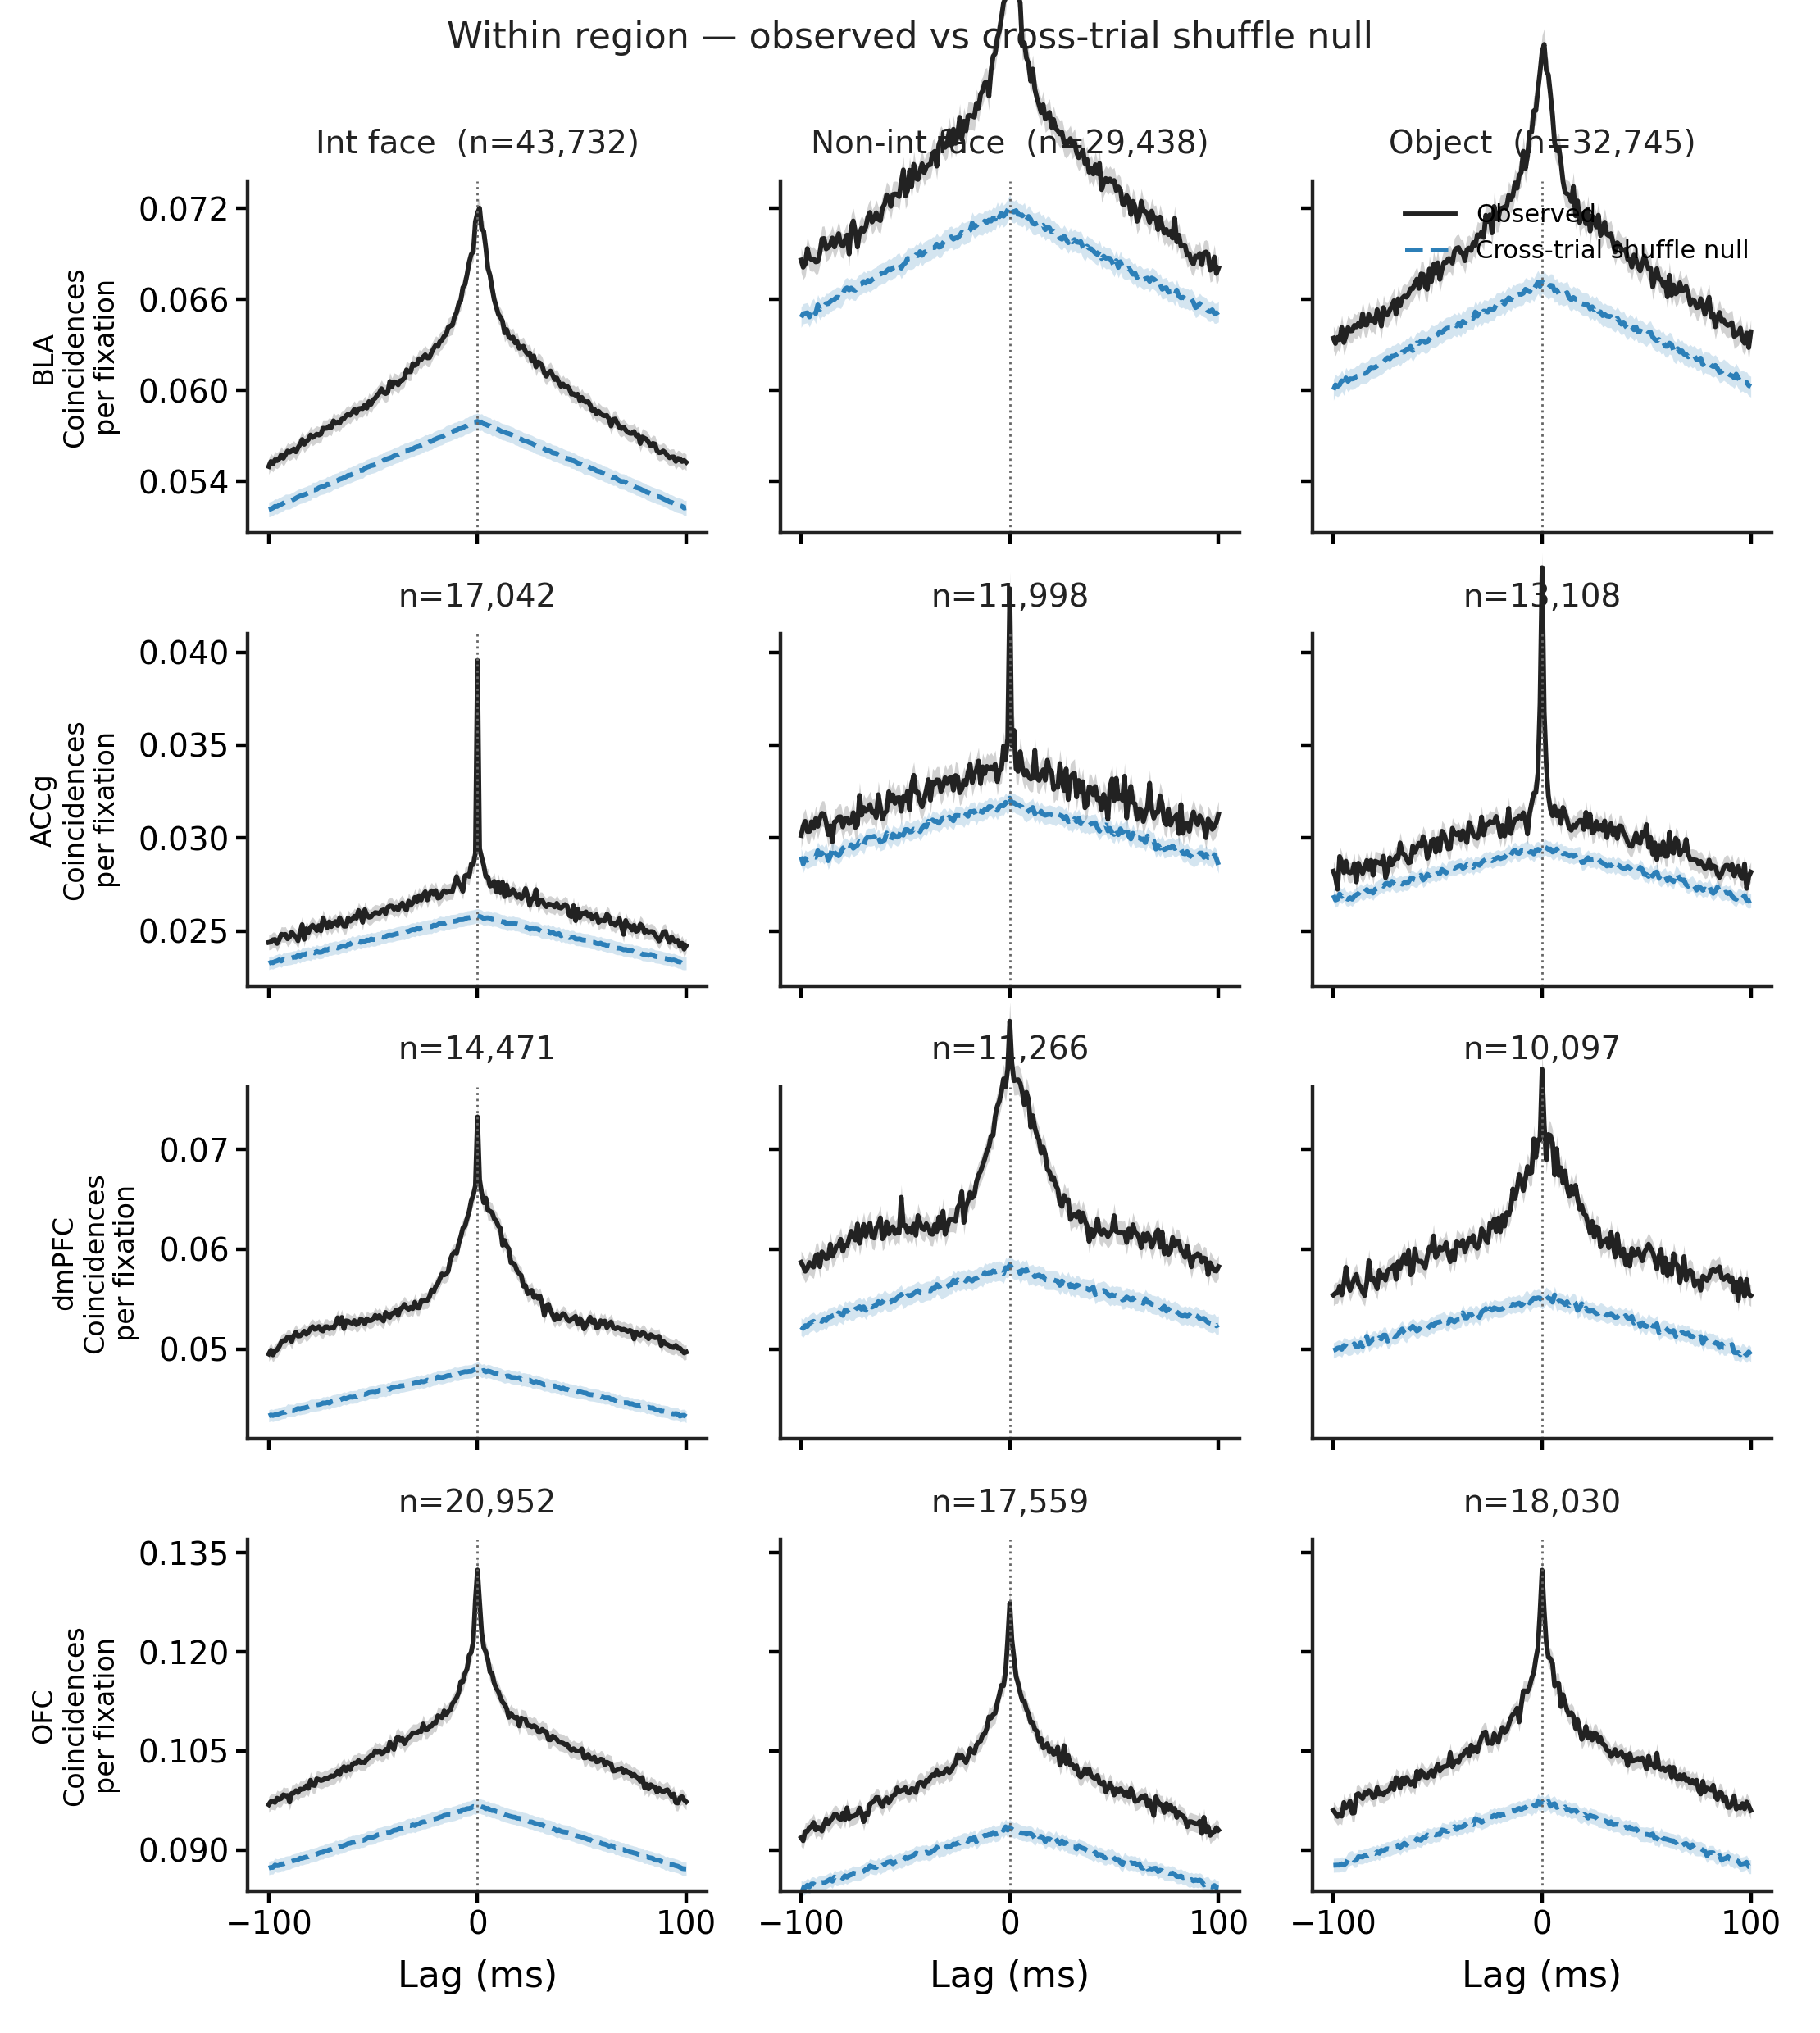

In [4]:
fig, paths = viz.plot_observed_and_null_grid(
    traces, figs, scope="within_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

## Null-corrected, and condition comparisons

Observed minus null, conditions overlaid within each region. Zero means no
coordination beyond what each unit's own fixation-locked rate profile predicts.

Contrasts are **paired within pair** — the same two neurons, electrodes and
session, differing only in which fixations were used. Benjamini–Hochberg
corrected; filled markers survived it.

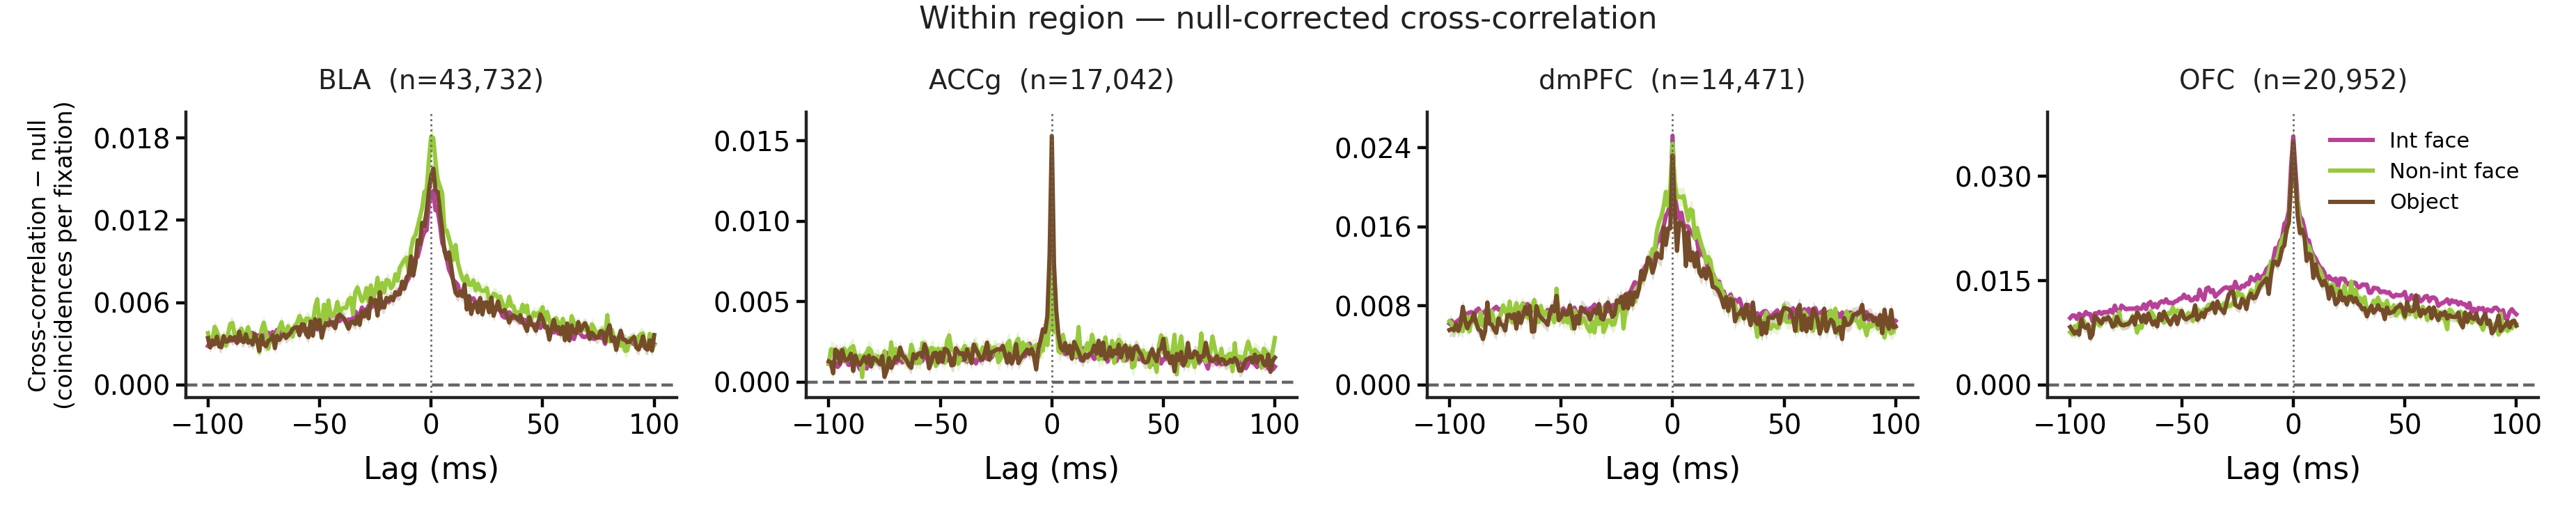

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
15,within_region,accg,face_interactive,face_non_interactive,11974,0.0036,0.0029,0.0007,30850383.0,0.0000,0.1347,0.0000,True,fdr_bh
16,within_region,accg,face_interactive,object,12991,0.0036,0.0037,-0.0000,39526188.0,0.0000,0.0919,0.0000,True,fdr_bh
17,within_region,accg,face_non_interactive,object,10494,0.0032,0.0041,-0.0009,25532543.5,0.0000,-0.0510,0.0000,True,fdr_bh
18,within_region,bla,face_interactive,face_non_interactive,29278,0.0141,0.0133,0.0008,197537869.0,0.0000,0.0867,0.0000,True,fdr_bh
19,within_region,bla,face_interactive,object,32477,0.0126,0.0115,0.0011,236738223.5,0.0000,0.0958,0.0000,True,fdr_bh
20,within_region,bla,face_non_interactive,object,24383,0.0142,0.0138,0.0005,146413513.5,0.0441,0.0008,0.0541,False,fdr_bh
21,within_region,dmpfc,face_interactive,face_non_interactive,11168,0.0197,0.0182,0.0015,27711553.0,0.0000,0.1119,0.0000,True,fdr_bh
22,within_region,dmpfc,face_interactive,object,10073,0.0204,0.0148,0.0056,20174946.5,0.0000,0.1575,0.0000,True,fdr_bh
23,within_region,dmpfc,face_non_interactive,object,8722,0.0206,0.0156,0.0049,17511225.0,0.0000,0.0369,0.0000,True,fdr_bh
24,within_region,ofc,face_interactive,face_non_interactive,17532,0.0253,0.0223,0.0030,67980372.0,0.0000,0.1102,0.0000,True,fdr_bh


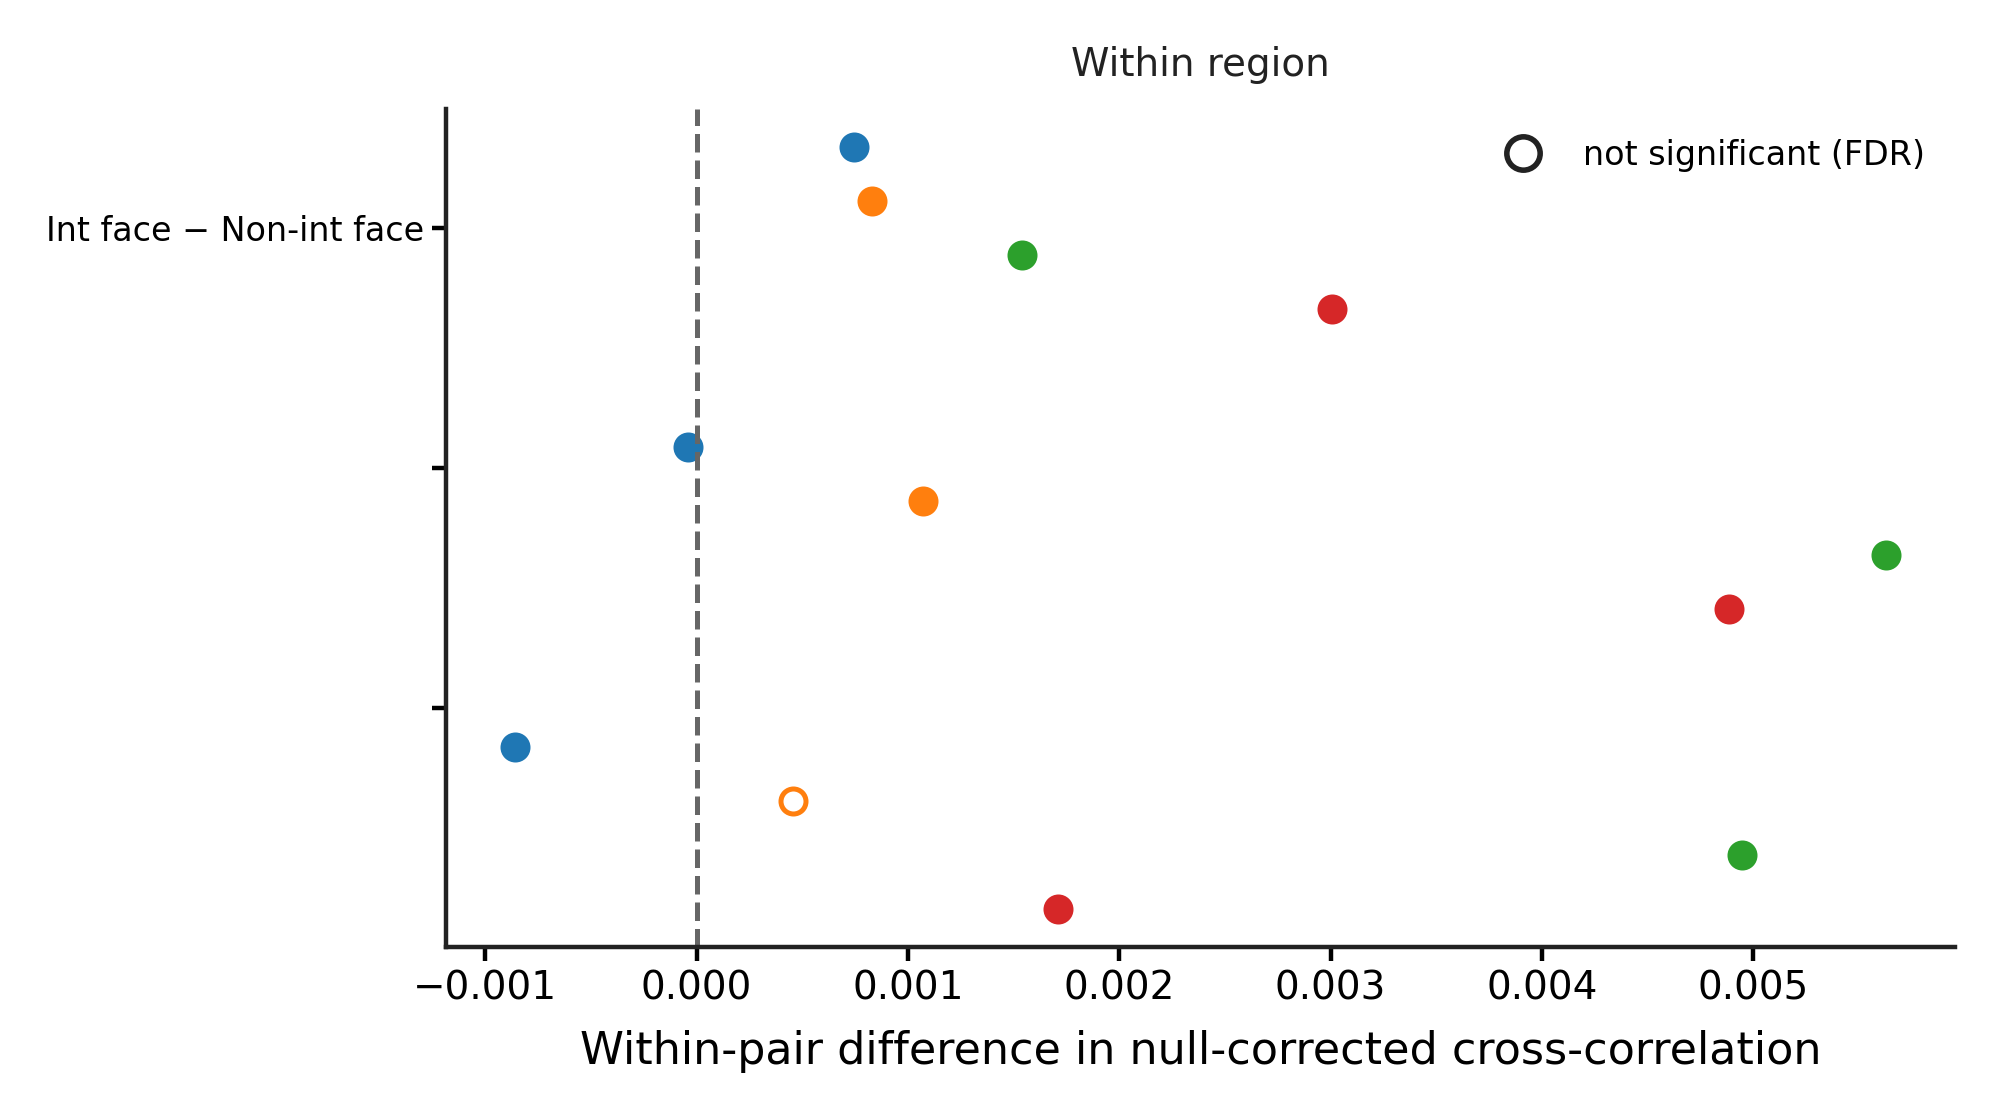

In [5]:
fig, paths = viz.plot_null_corrected_grid(
    traces, figs, scope="within_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

subset = contrasts.loc[contrasts["scope"] == "within_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts, figs, scope="within_region"
)
display(Image(filename=str(paths["png"])))

# 2. Within region — FDR-selective pairs

Pairs where **both** units are significantly selective for at least one
fixation-condition contrast (FDR-corrected, `three_condition_core`).

Selecting units by a condition contrast and then asking whether coordination
differs by condition is circular, so this is a sensitivity check rather than
independent confirmation. What it can show is whether an effect is carried by
the selective subset or is distributed across the population.

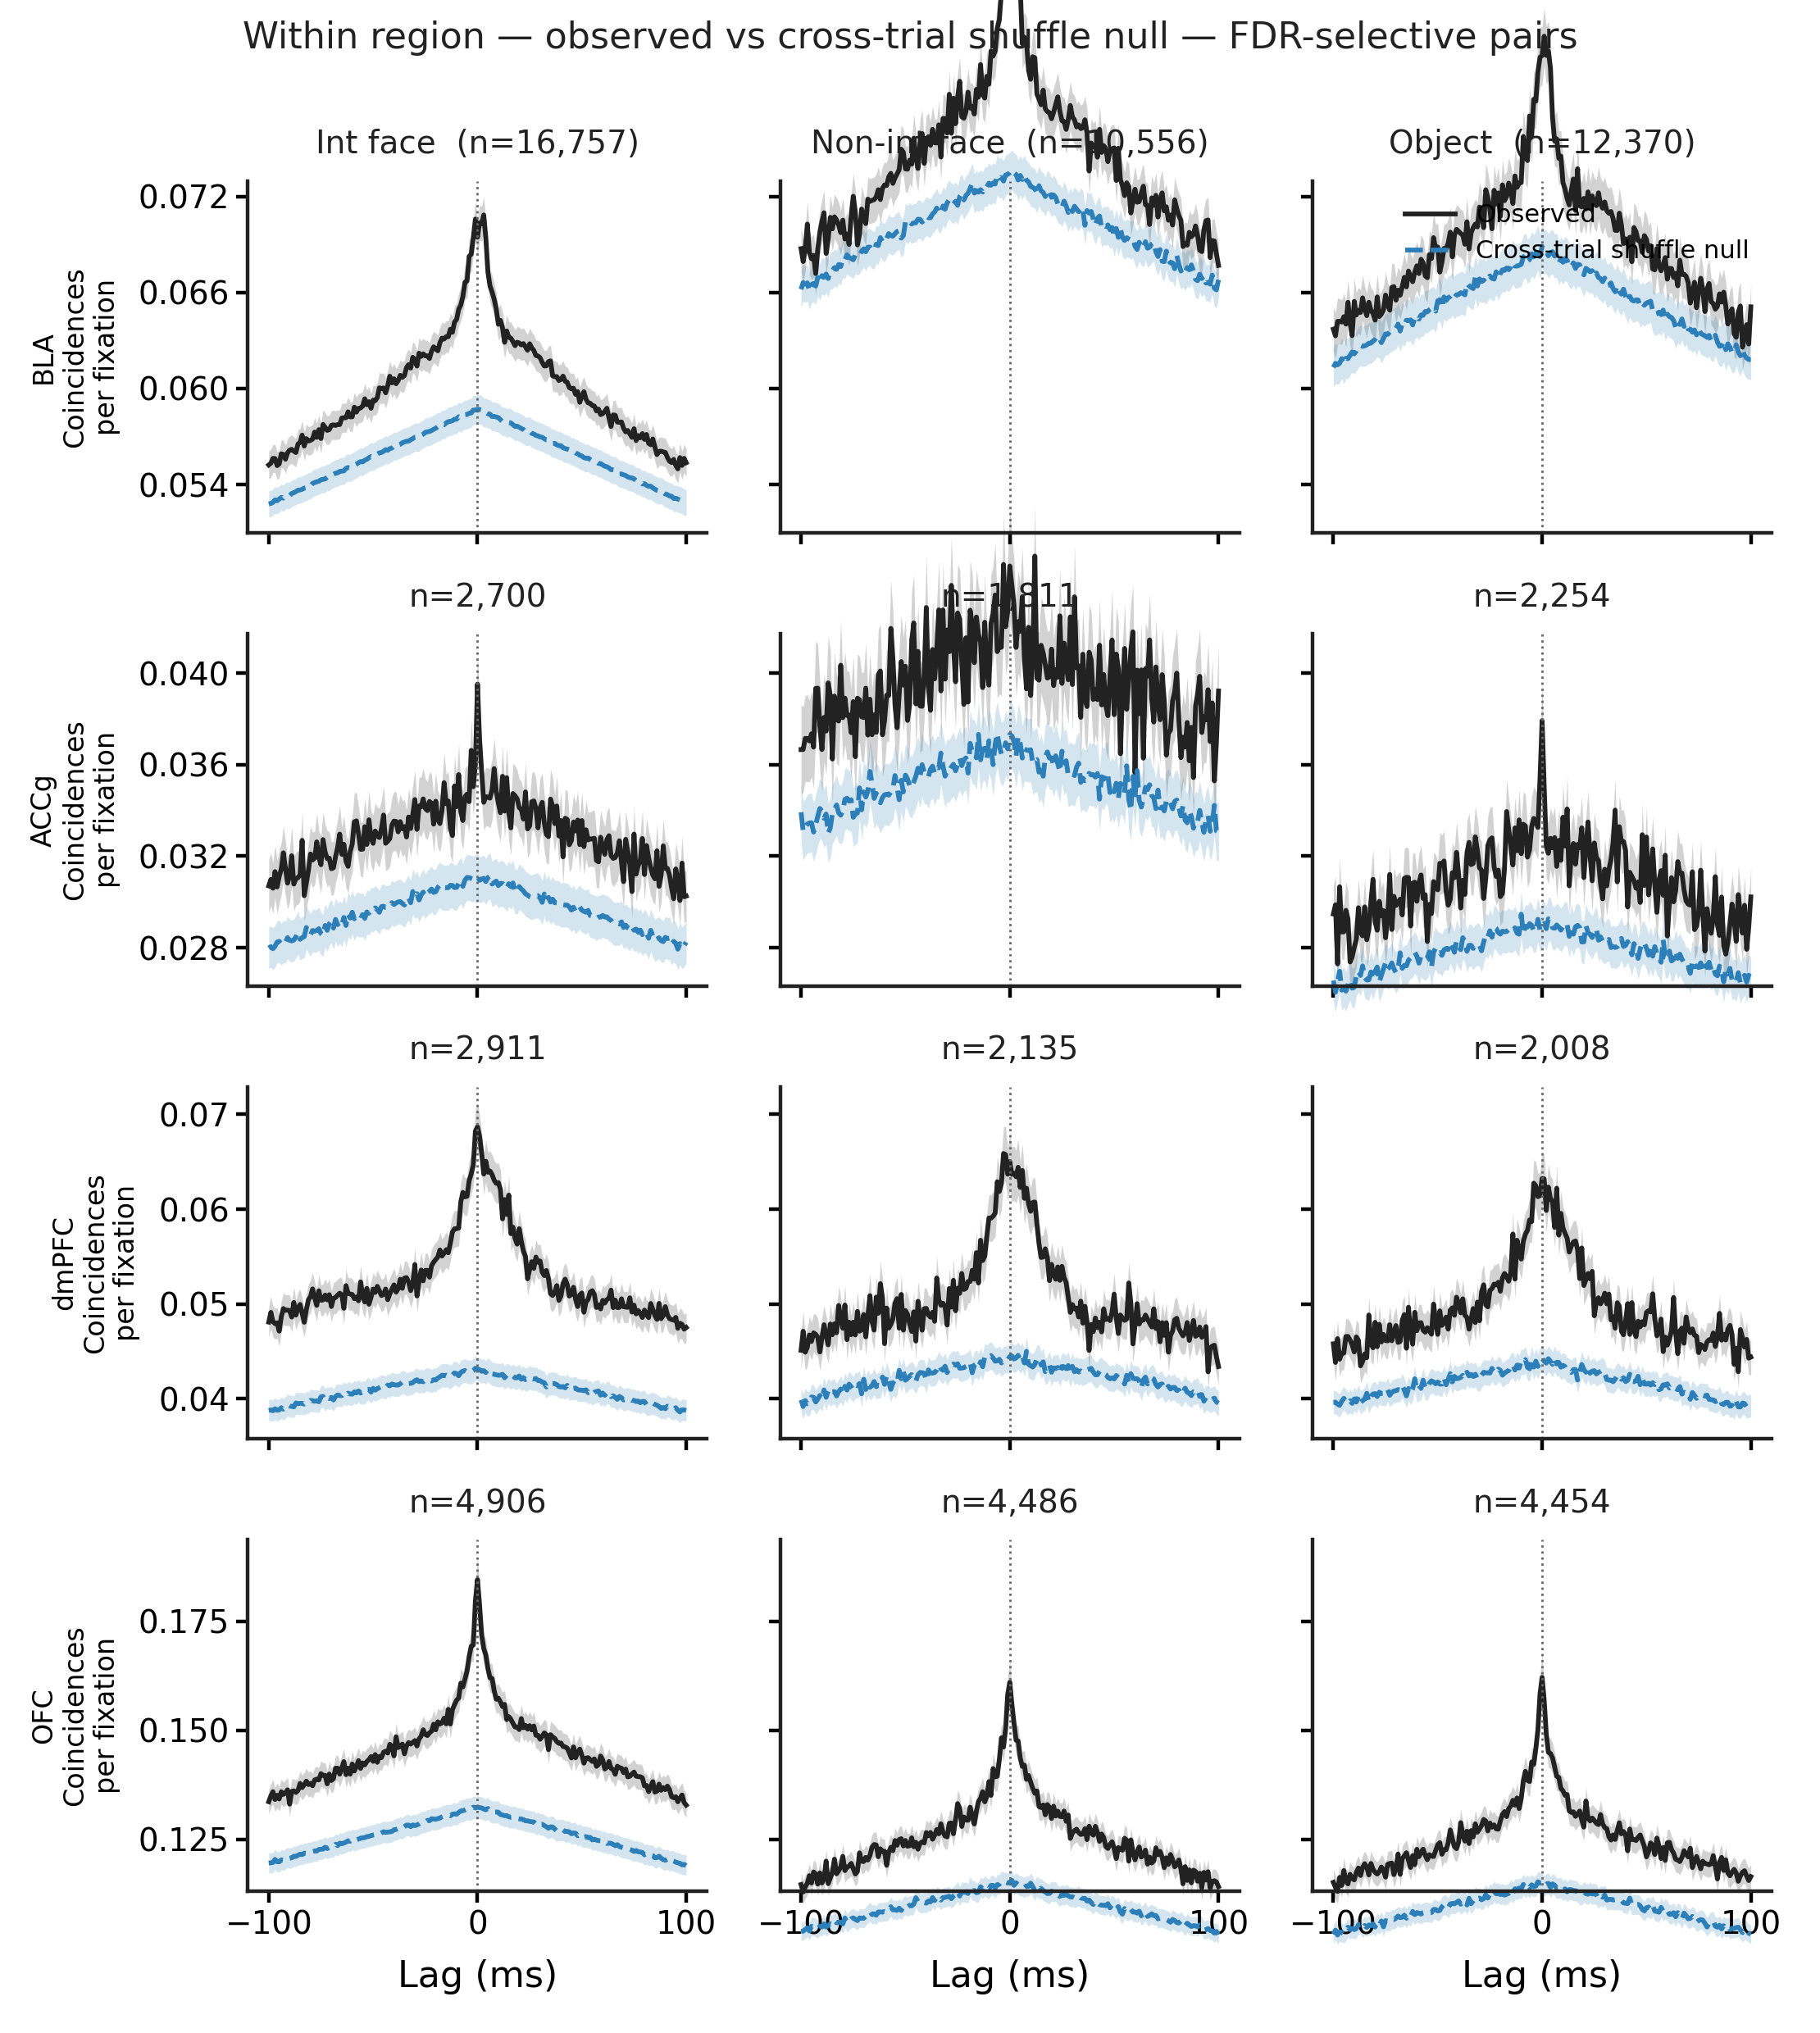

In [6]:
fig, paths = viz.plot_observed_and_null_grid(
    traces_sig, figs, scope="within_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

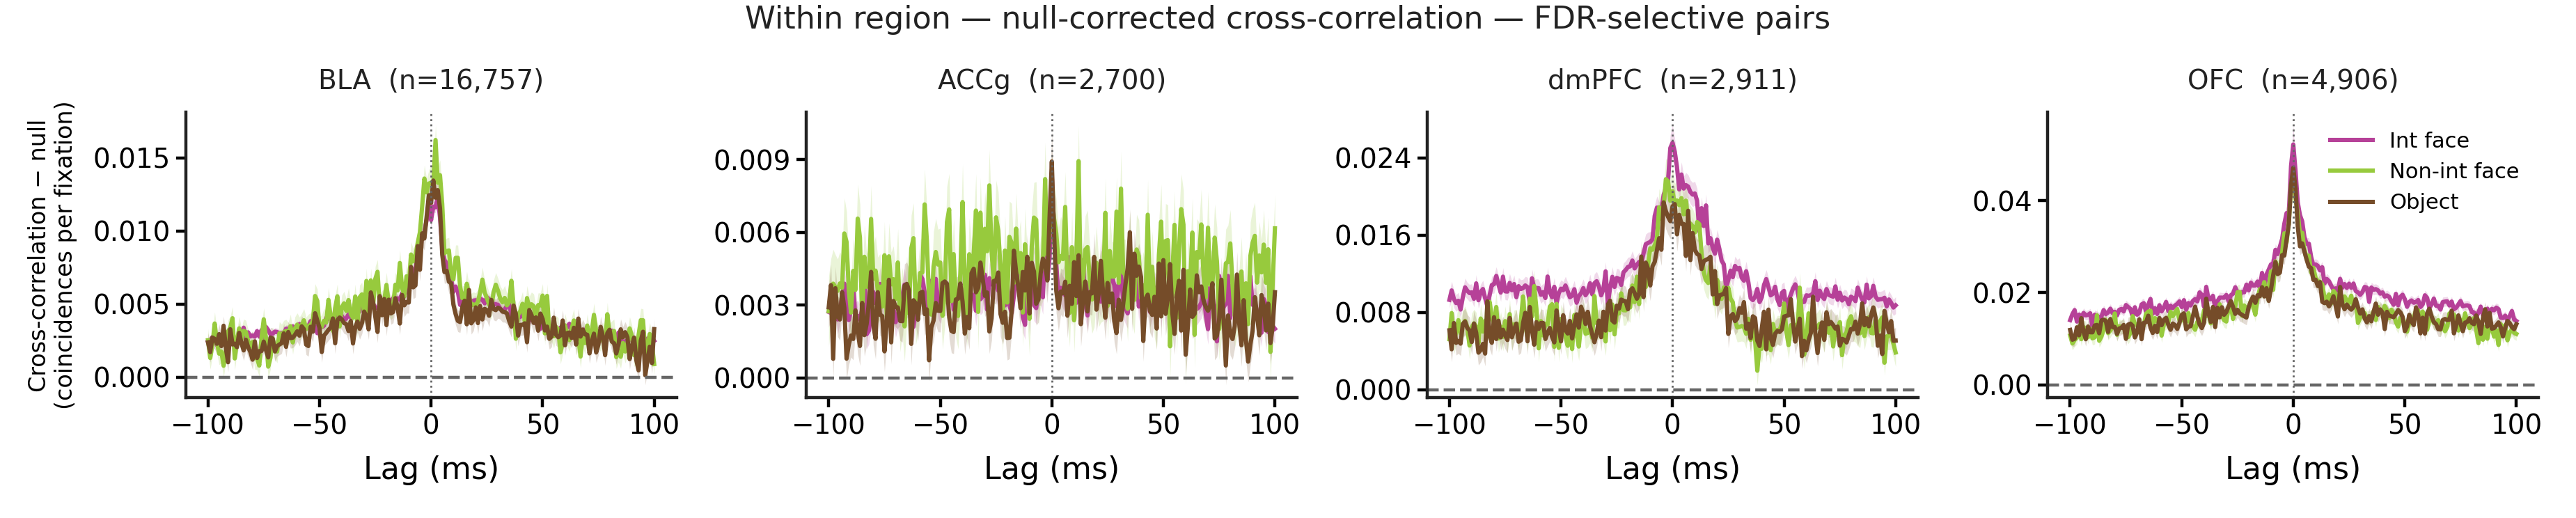

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
12,within_region,accg,face_interactive,face_non_interactive,1810,0.0053,0.0055,-0.0002,720054.0,0.0000,0.1436,0.0000,True,fdr_bh
13,within_region,accg,face_interactive,object,2229,0.0050,0.0044,0.0007,1133013.0,0.0003,0.0947,0.0006,True,fdr_bh
14,within_region,accg,face_non_interactive,object,1671,0.0059,0.0050,0.0008,659125.5,0.0461,-0.0664,0.0582,False,fdr_bh
15,within_region,bla,face_interactive,face_non_interactive,10537,0.0127,0.0110,0.0016,24932952.5,0.0000,0.1041,0.0000,True,fdr_bh
16,within_region,bla,face_interactive,object,12307,0.0109,0.0093,0.0016,32633027.0,0.0000,0.1228,0.0000,True,fdr_bh
17,within_region,bla,face_non_interactive,object,8671,0.0118,0.0115,0.0002,18271872.0,0.0238,0.0126,0.0322,True,fdr_bh
18,within_region,dmpfc,face_interactive,face_non_interactive,2097,0.0244,0.0188,0.0056,902572.0,0.0000,0.1588,0.0000,True,fdr_bh
19,within_region,dmpfc,face_interactive,object,2008,0.0267,0.0165,0.0102,756304.0,0.0000,0.1633,0.0000,True,fdr_bh
20,within_region,dmpfc,face_non_interactive,object,1609,0.0213,0.0168,0.0044,635710.5,0.5228,-0.0230,0.5975,False,fdr_bh
21,within_region,ofc,face_interactive,face_non_interactive,4486,0.0372,0.0312,0.0060,4207009.0,0.0000,0.1320,0.0000,True,fdr_bh


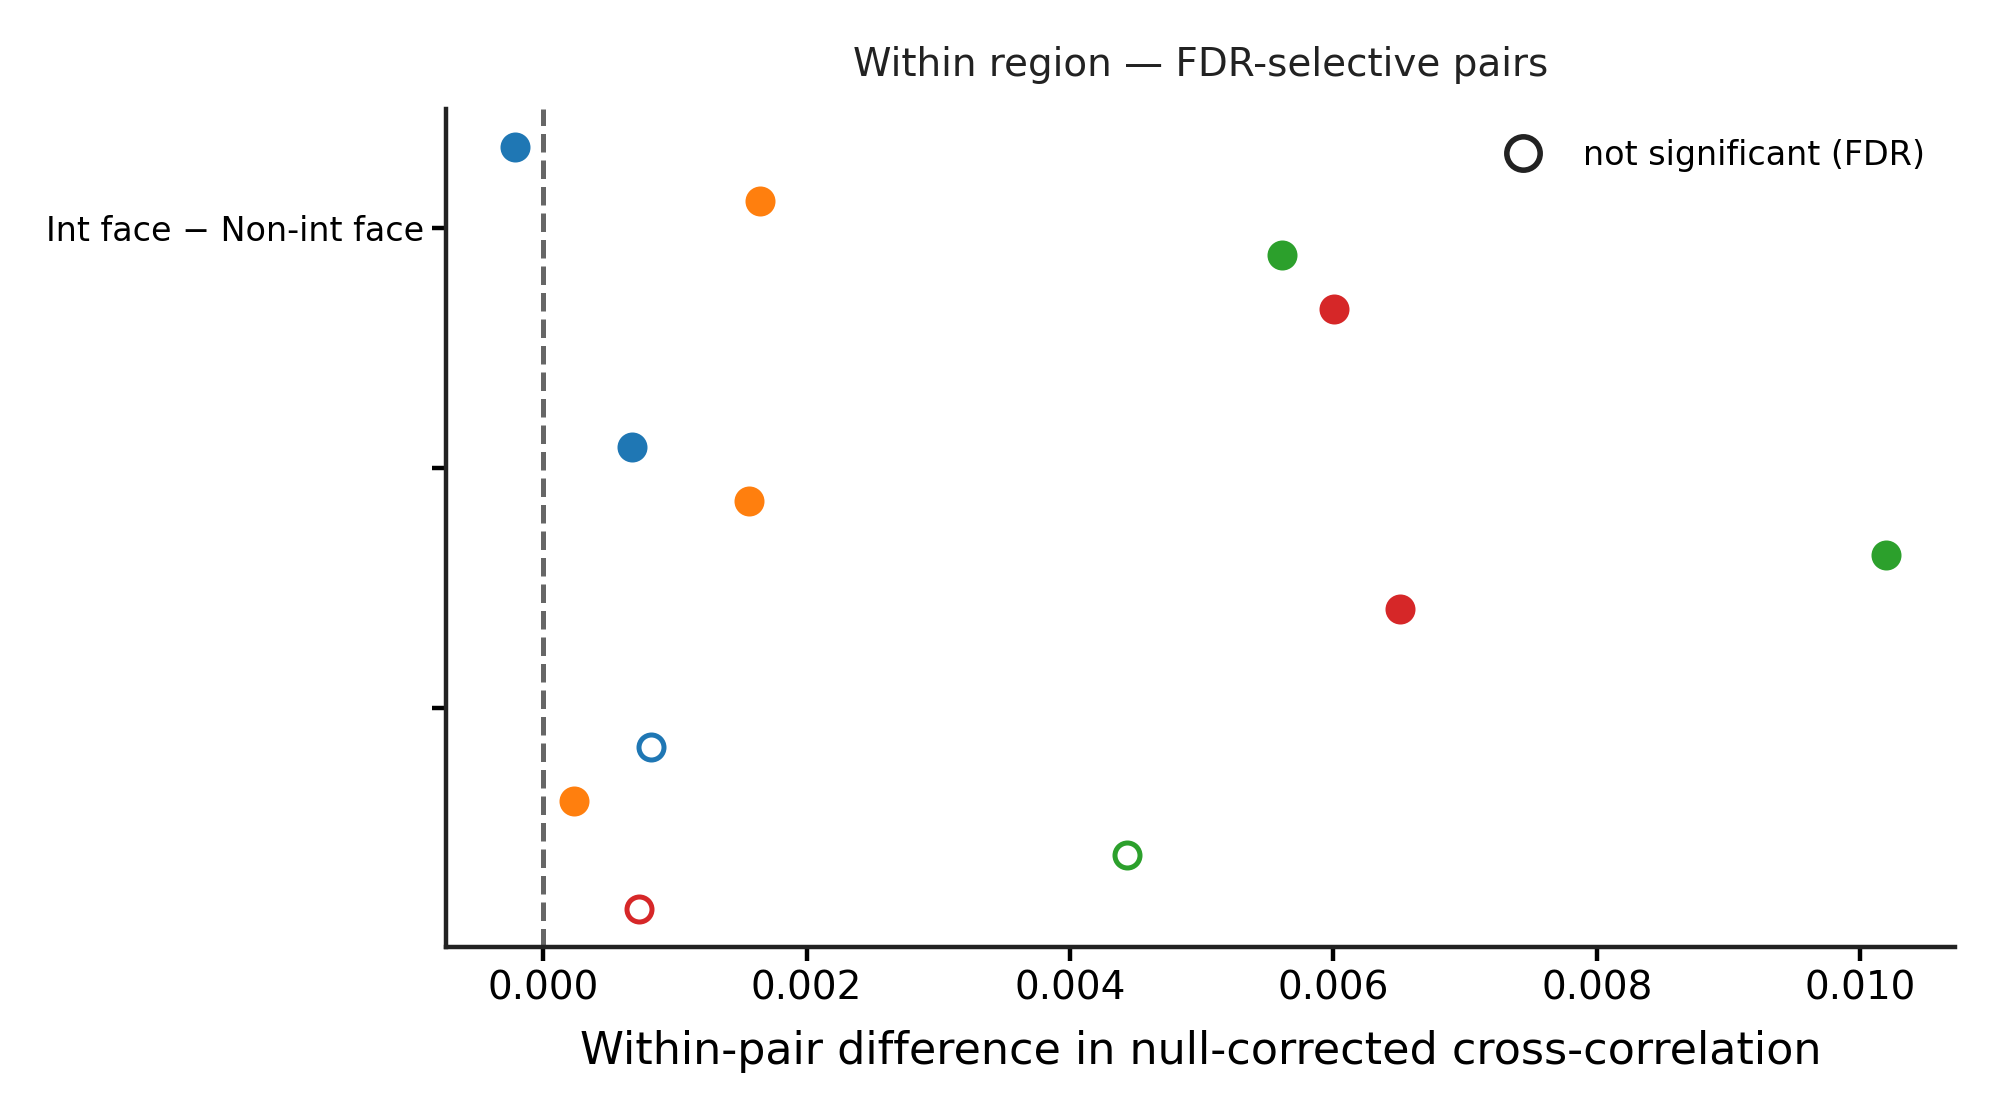

In [7]:
fig, paths = viz.plot_null_corrected_grid(
    traces_sig, figs, scope="within_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

subset = contrasts_sig.loc[contrasts_sig["scope"] == "within_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts_sig, figs, scope="within_region", label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

# 3. Across regions — all pairs

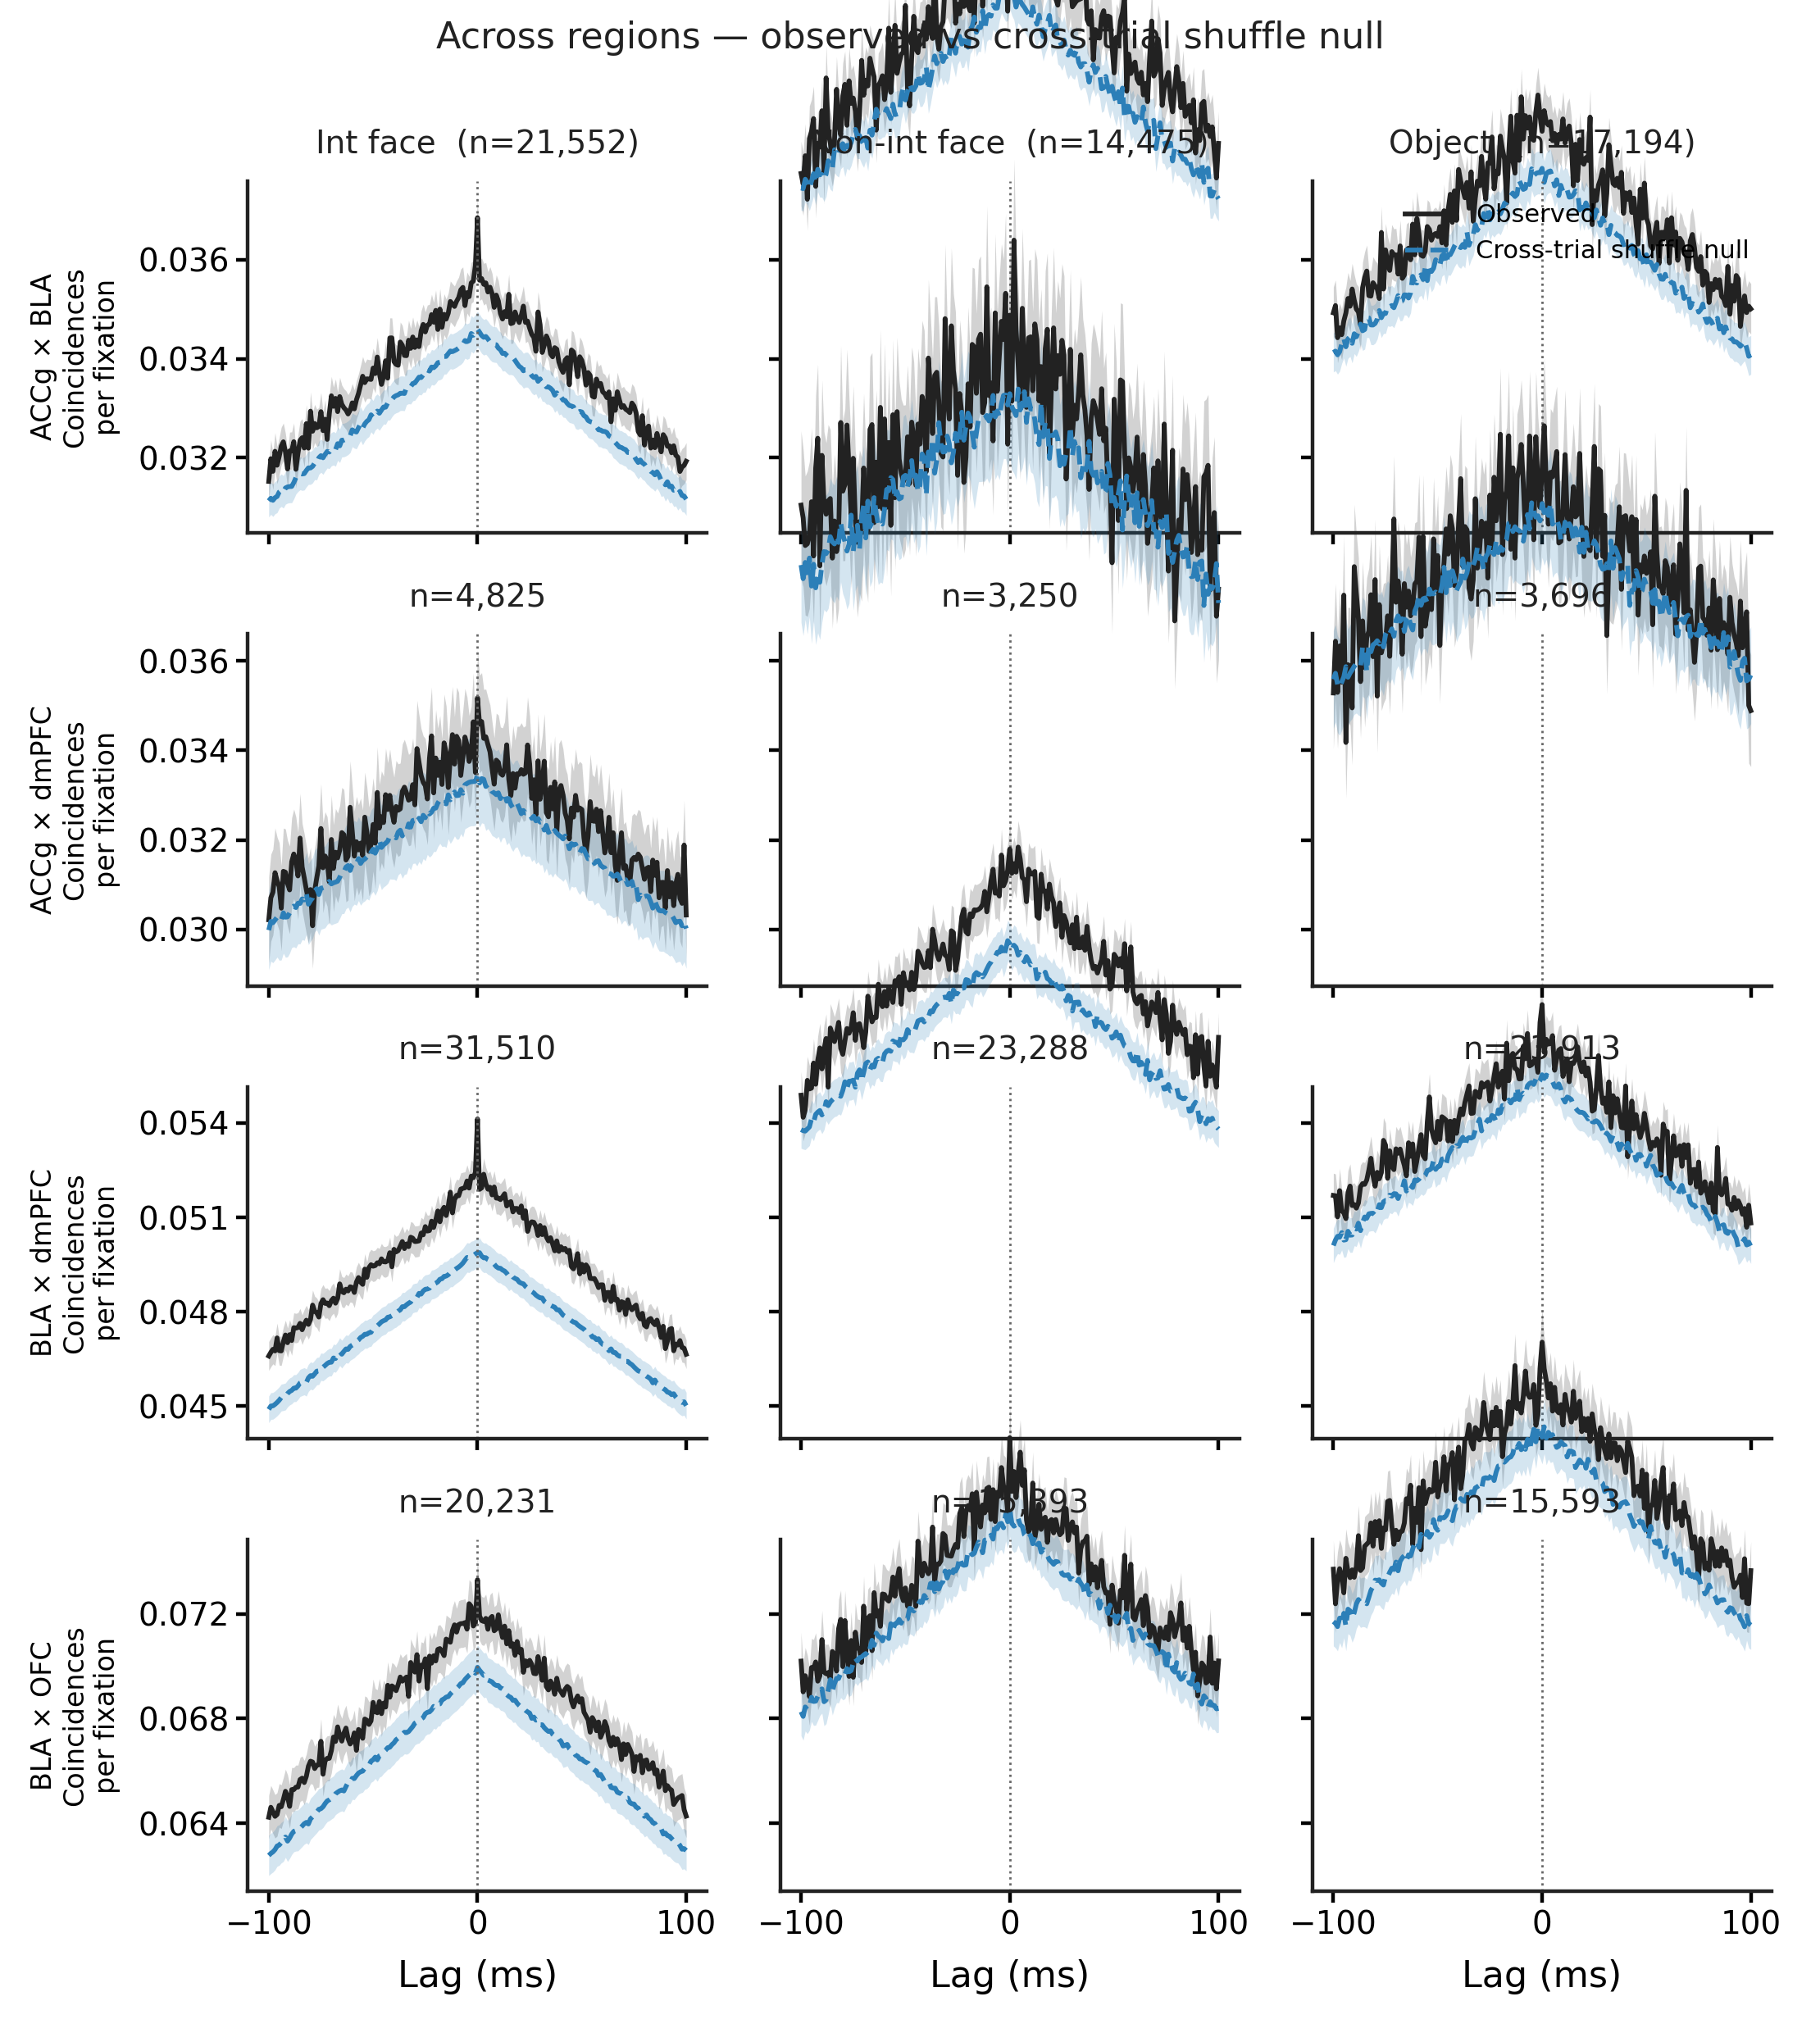

In [8]:
fig, paths = viz.plot_observed_and_null_grid(
    traces, figs, scope="cross_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

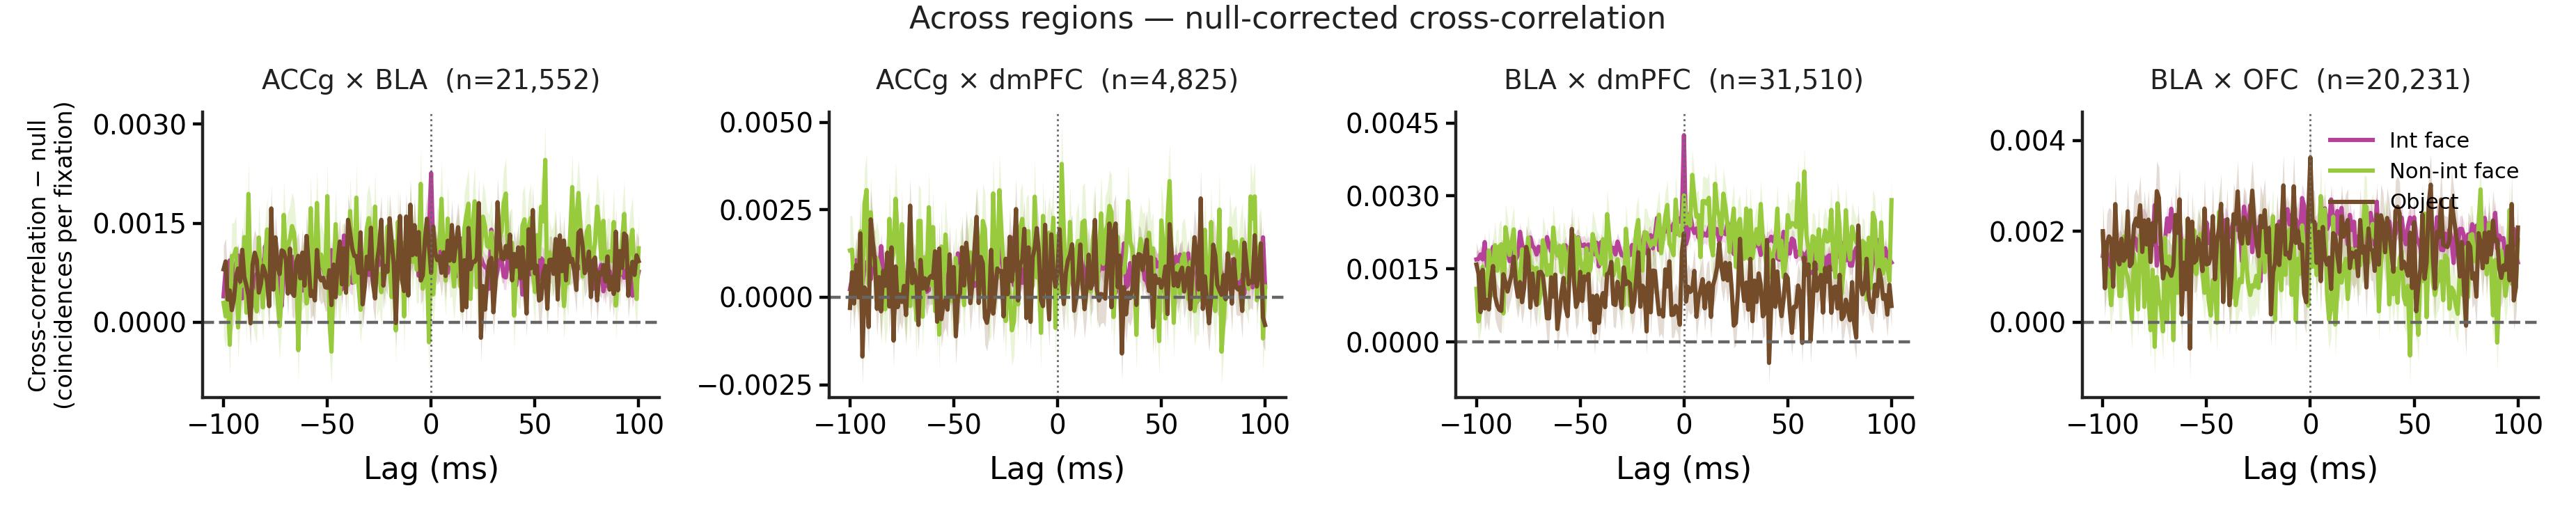

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,14405,0.0012,0.0010,0.0002,48081448.0,0.0000,0.0898,0.0000,True,fdr_bh
1,cross_region,accg-bla,face_interactive,object,17066,0.0013,0.0011,0.0002,69333684.5,0.0000,0.0557,0.0000,True,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,12515,0.0011,0.0012,-0.0001,37597479.0,0.0001,-0.0455,0.0002,True,fdr_bh
3,cross_region,accg-dmpfc,face_interactive,face_non_interactive,3227,0.0008,0.0011,-0.0004,2531507.5,0.1697,0.0728,0.1992,False,fdr_bh
4,cross_region,accg-dmpfc,face_interactive,object,3669,0.0010,0.0007,0.0003,3203163.0,0.0110,0.0673,0.0142,True,fdr_bh
5,cross_region,accg-dmpfc,face_non_interactive,object,2821,0.0012,0.0008,0.0004,1948988.0,0.3406,-0.0067,0.3679,False,fdr_bh
6,cross_region,bla-dmpfc,face_interactive,face_non_interactive,23102,0.0028,0.0025,0.0003,122826557.5,0.0000,0.0919,0.0000,True,fdr_bh
7,cross_region,bla-dmpfc,face_interactive,object,23786,0.0030,0.0011,0.0019,122124459.5,0.0000,0.1289,0.0000,True,fdr_bh
8,cross_region,bla-dmpfc,face_non_interactive,object,19209,0.0028,0.0012,0.0016,90240173.5,0.0092,0.0031,0.0124,True,fdr_bh
9,cross_region,bla-ofc,face_interactive,face_non_interactive,15352,0.0021,0.0014,0.0007,54640636.5,0.0000,0.0857,0.0000,True,fdr_bh


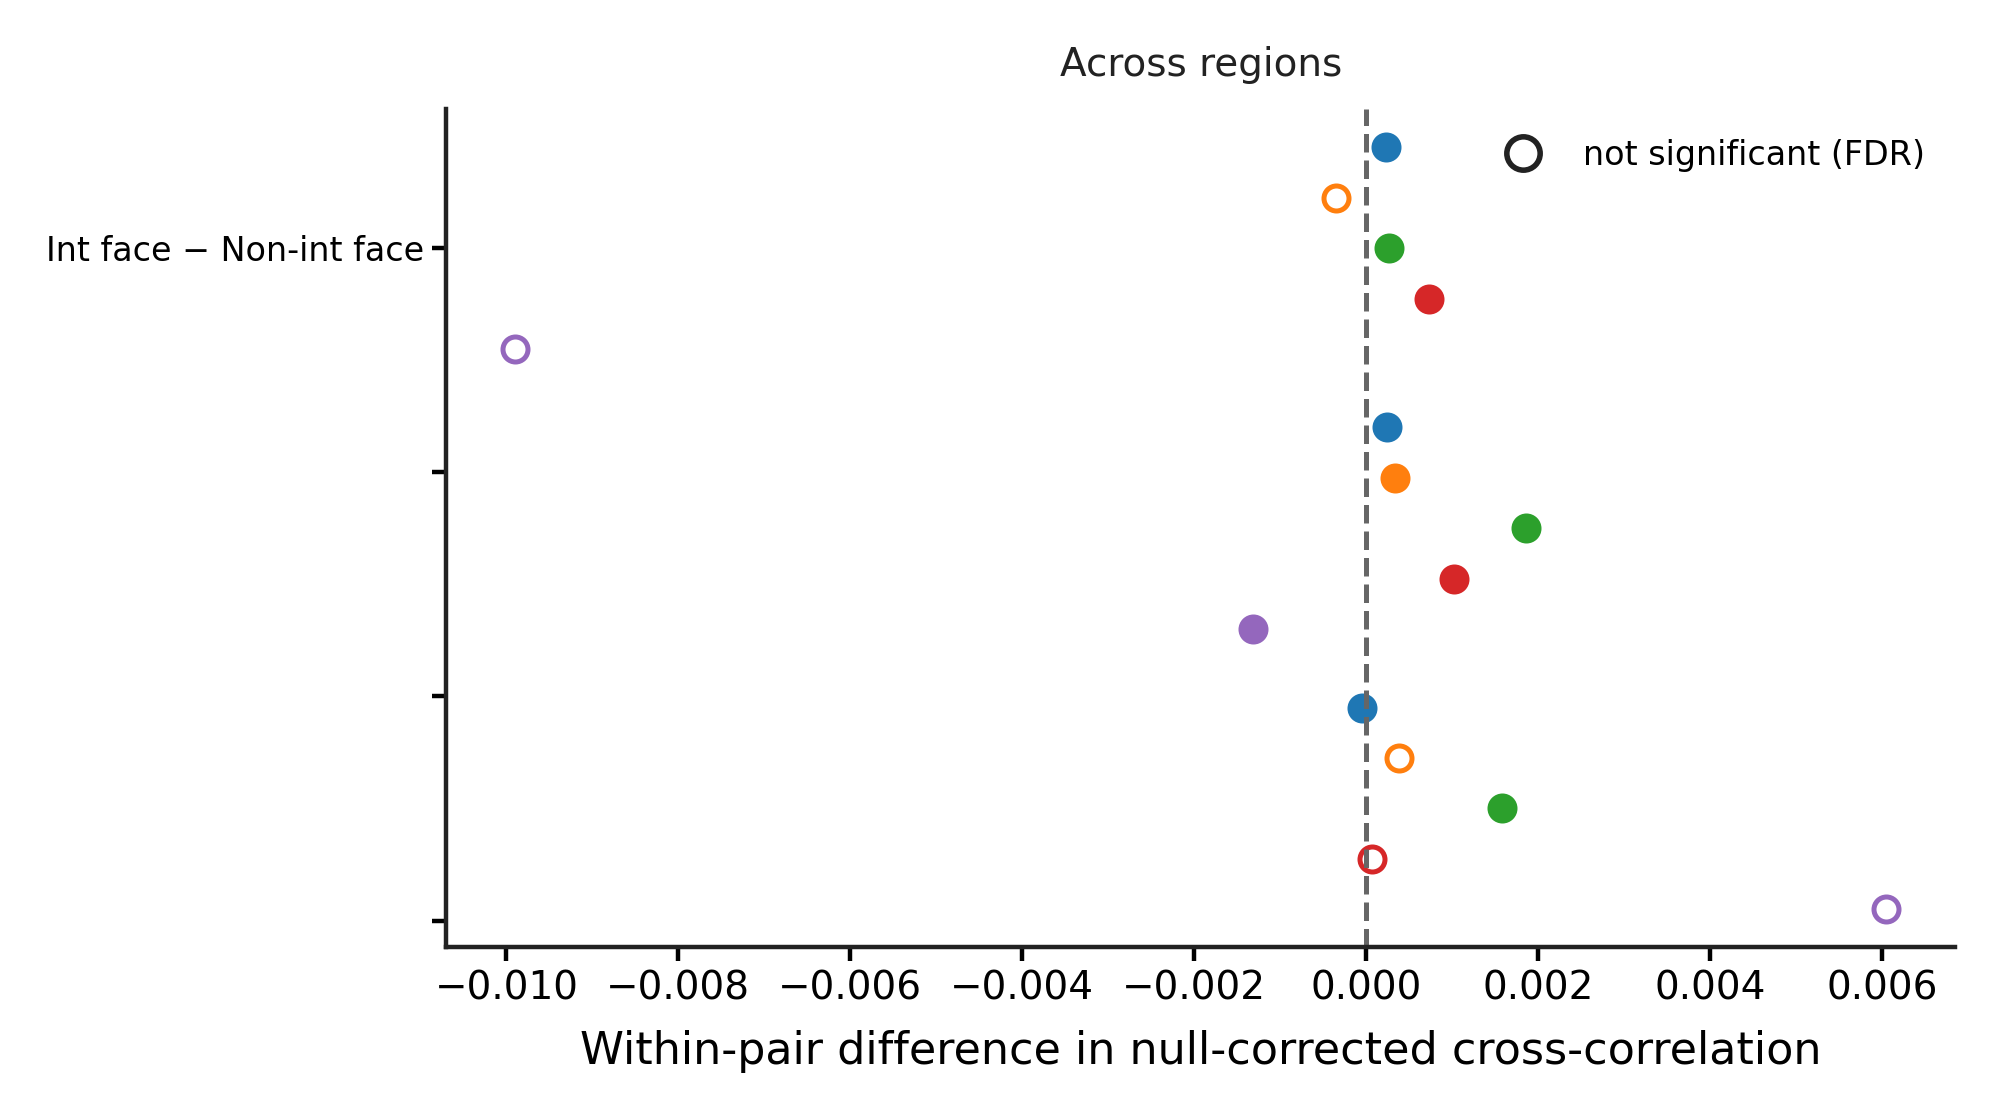

In [9]:
fig, paths = viz.plot_null_corrected_grid(
    traces, figs, scope="cross_region", min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

subset = contrasts.loc[contrasts["scope"] == "cross_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts, figs, scope="cross_region"
)
display(Image(filename=str(paths["png"])))

# 4. Across regions — FDR-selective pairs

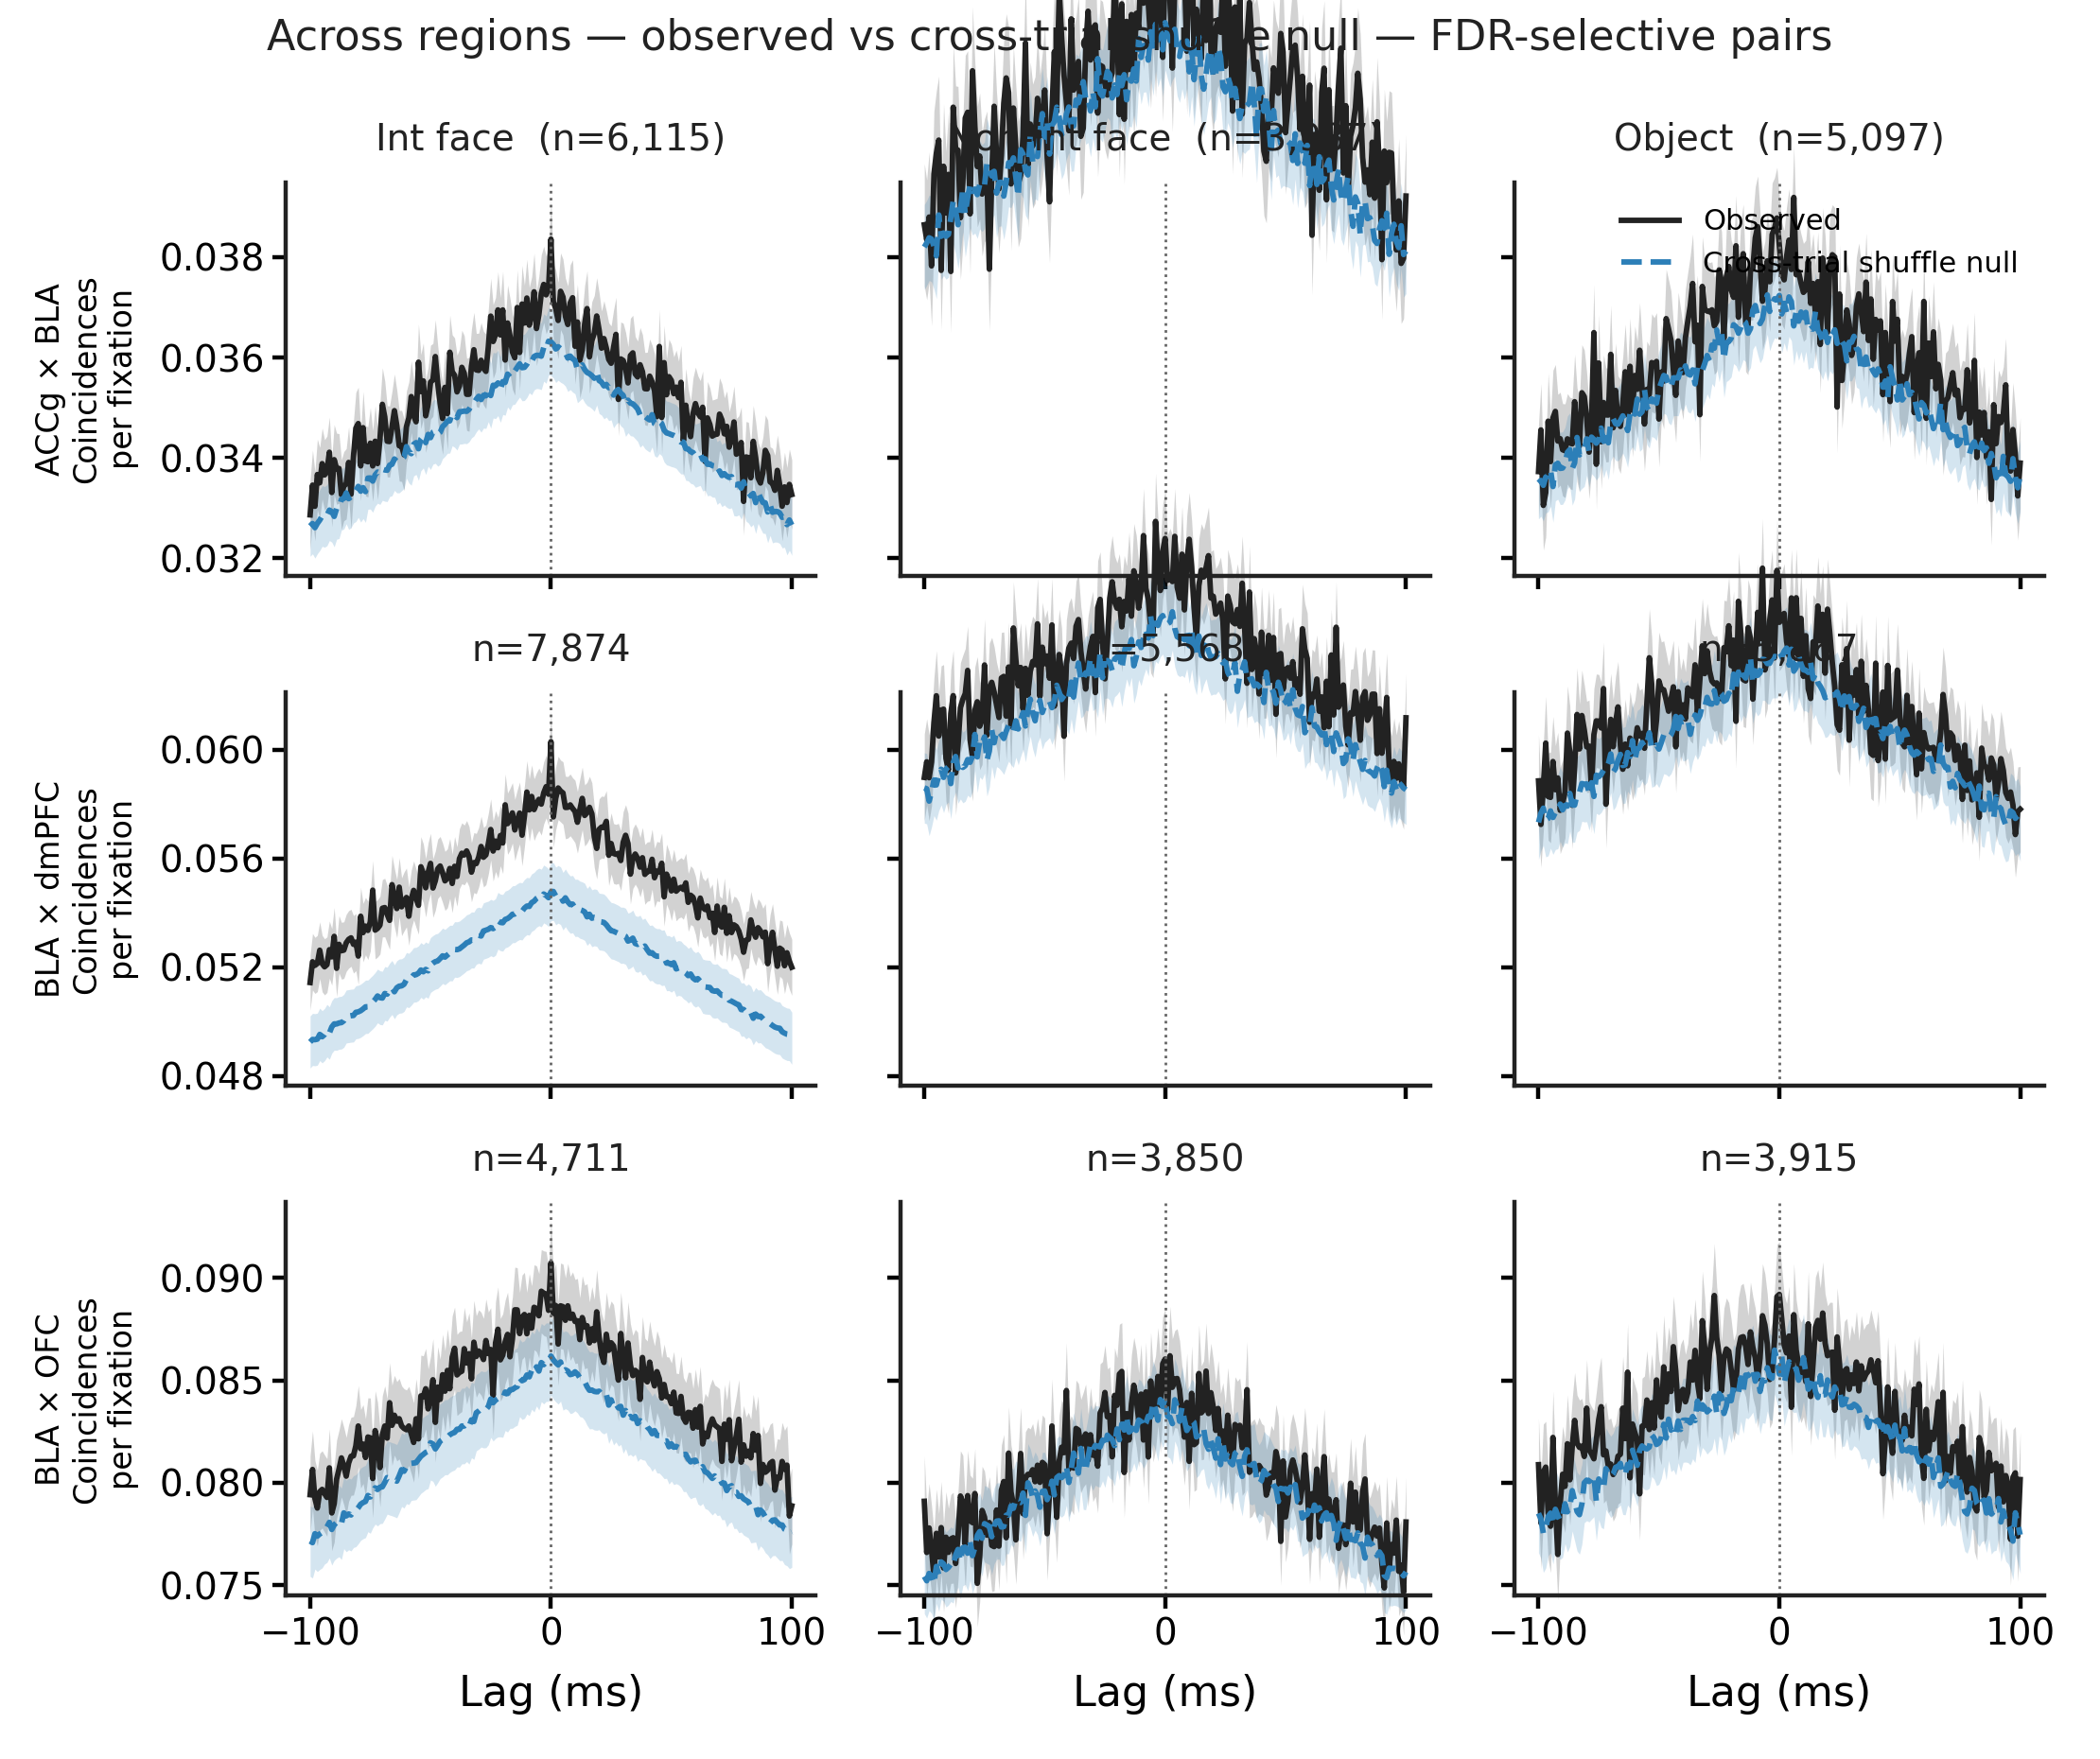

In [10]:
fig, paths = viz.plot_observed_and_null_grid(
    traces_sig, figs, scope="cross_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

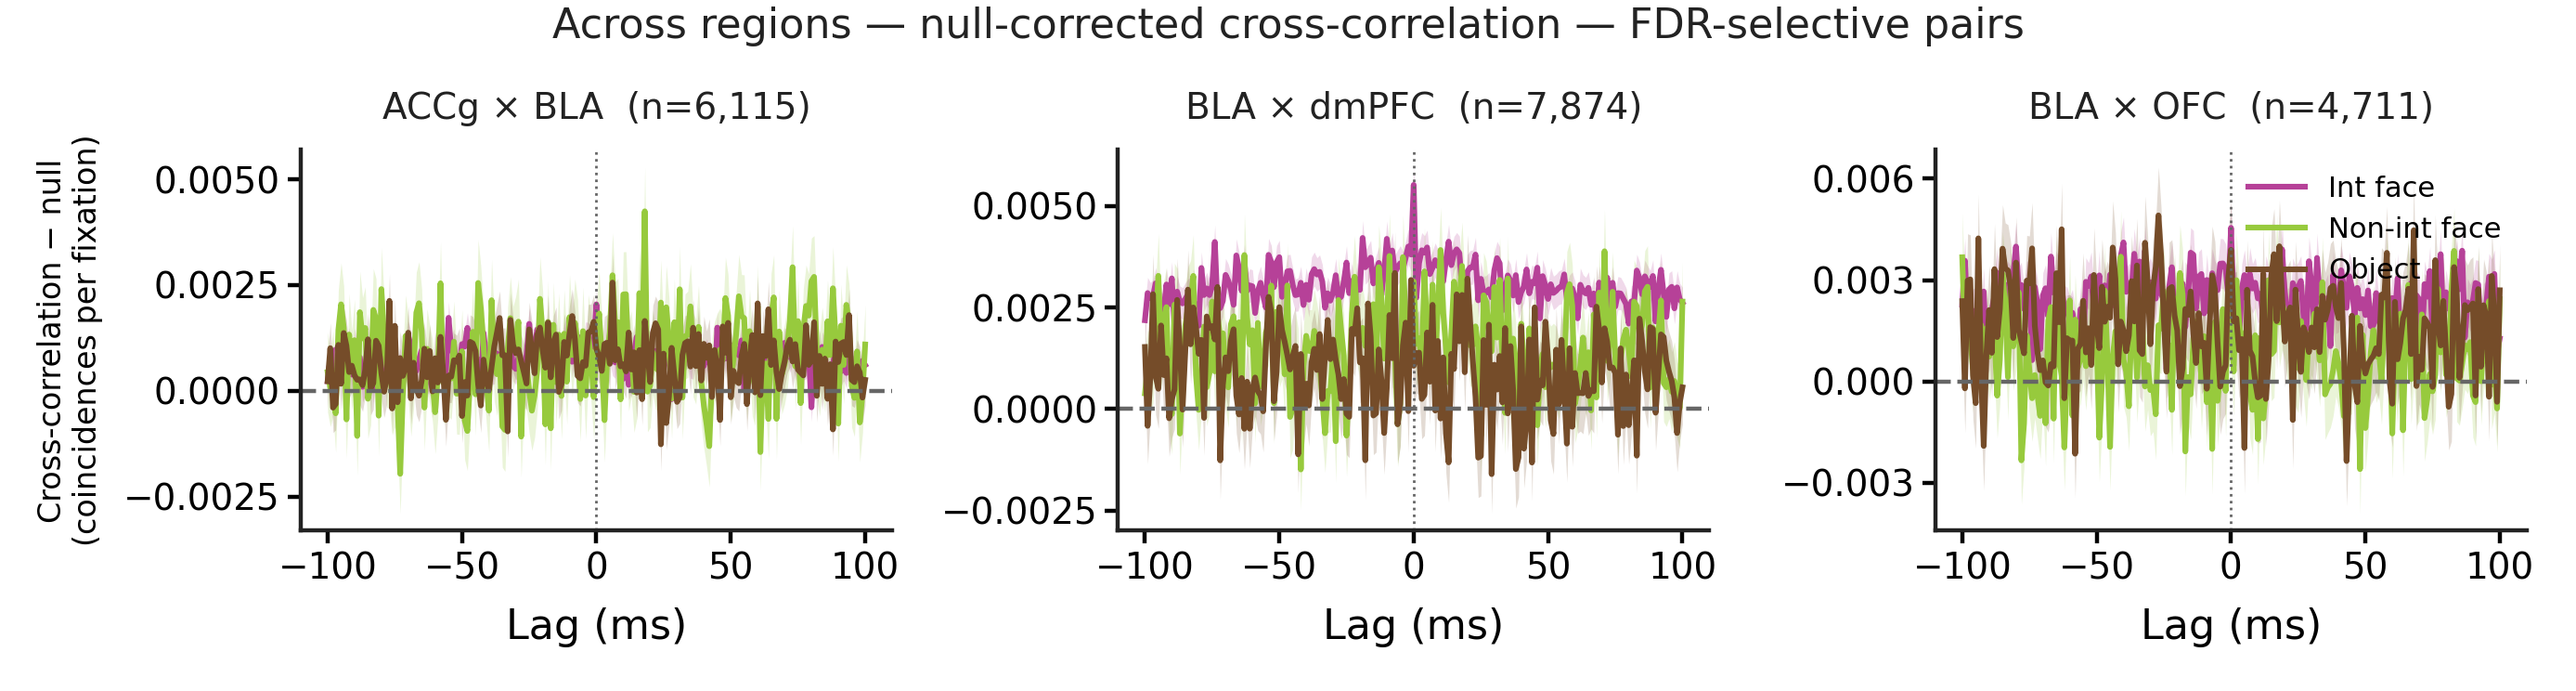

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,3966,0.0011,0.0009,0.0002,3634582.0,0.0000,0.0958,0.0001,True,fdr_bh
1,cross_region,accg-bla,face_interactive,object,5056,0.0012,0.0010,0.0001,6158029.0,0.0242,0.0601,0.0322,True,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,3511,0.0011,0.0012,-0.0001,2932086.0,0.0122,-0.0624,0.0195,True,fdr_bh
3,cross_region,accg-dmpfc,face_interactive,face_non_interactive,168,0.0010,-0.0005,0.0016,5373.0,0.0063,0.2738,0.0108,True,fdr_bh
4,cross_region,accg-dmpfc,face_interactive,object,220,0.0011,-0.0002,0.0013,9889.0,0.0165,0.1909,0.0248,True,fdr_bh
5,cross_region,accg-dmpfc,face_non_interactive,object,135,-0.0005,-0.0004,-0.0002,4388.0,0.6573,-0.0667,0.6859,False,fdr_bh
6,cross_region,bla-dmpfc,face_interactive,face_non_interactive,5524,0.0041,0.0019,0.0022,6670523.0,0.0000,0.1068,0.0000,True,fdr_bh
7,cross_region,bla-dmpfc,face_interactive,object,5836,0.0047,0.0013,0.0033,7033940.5,0.0000,0.1518,0.0000,True,fdr_bh
8,cross_region,bla-dmpfc,face_non_interactive,object,4584,0.0021,0.0014,0.0008,5247764.5,0.9409,-0.0100,0.9409,False,fdr_bh
9,cross_region,bla-ofc,face_interactive,face_non_interactive,3847,0.0030,0.0008,0.0022,3336975.5,0.0000,0.0780,0.0000,True,fdr_bh


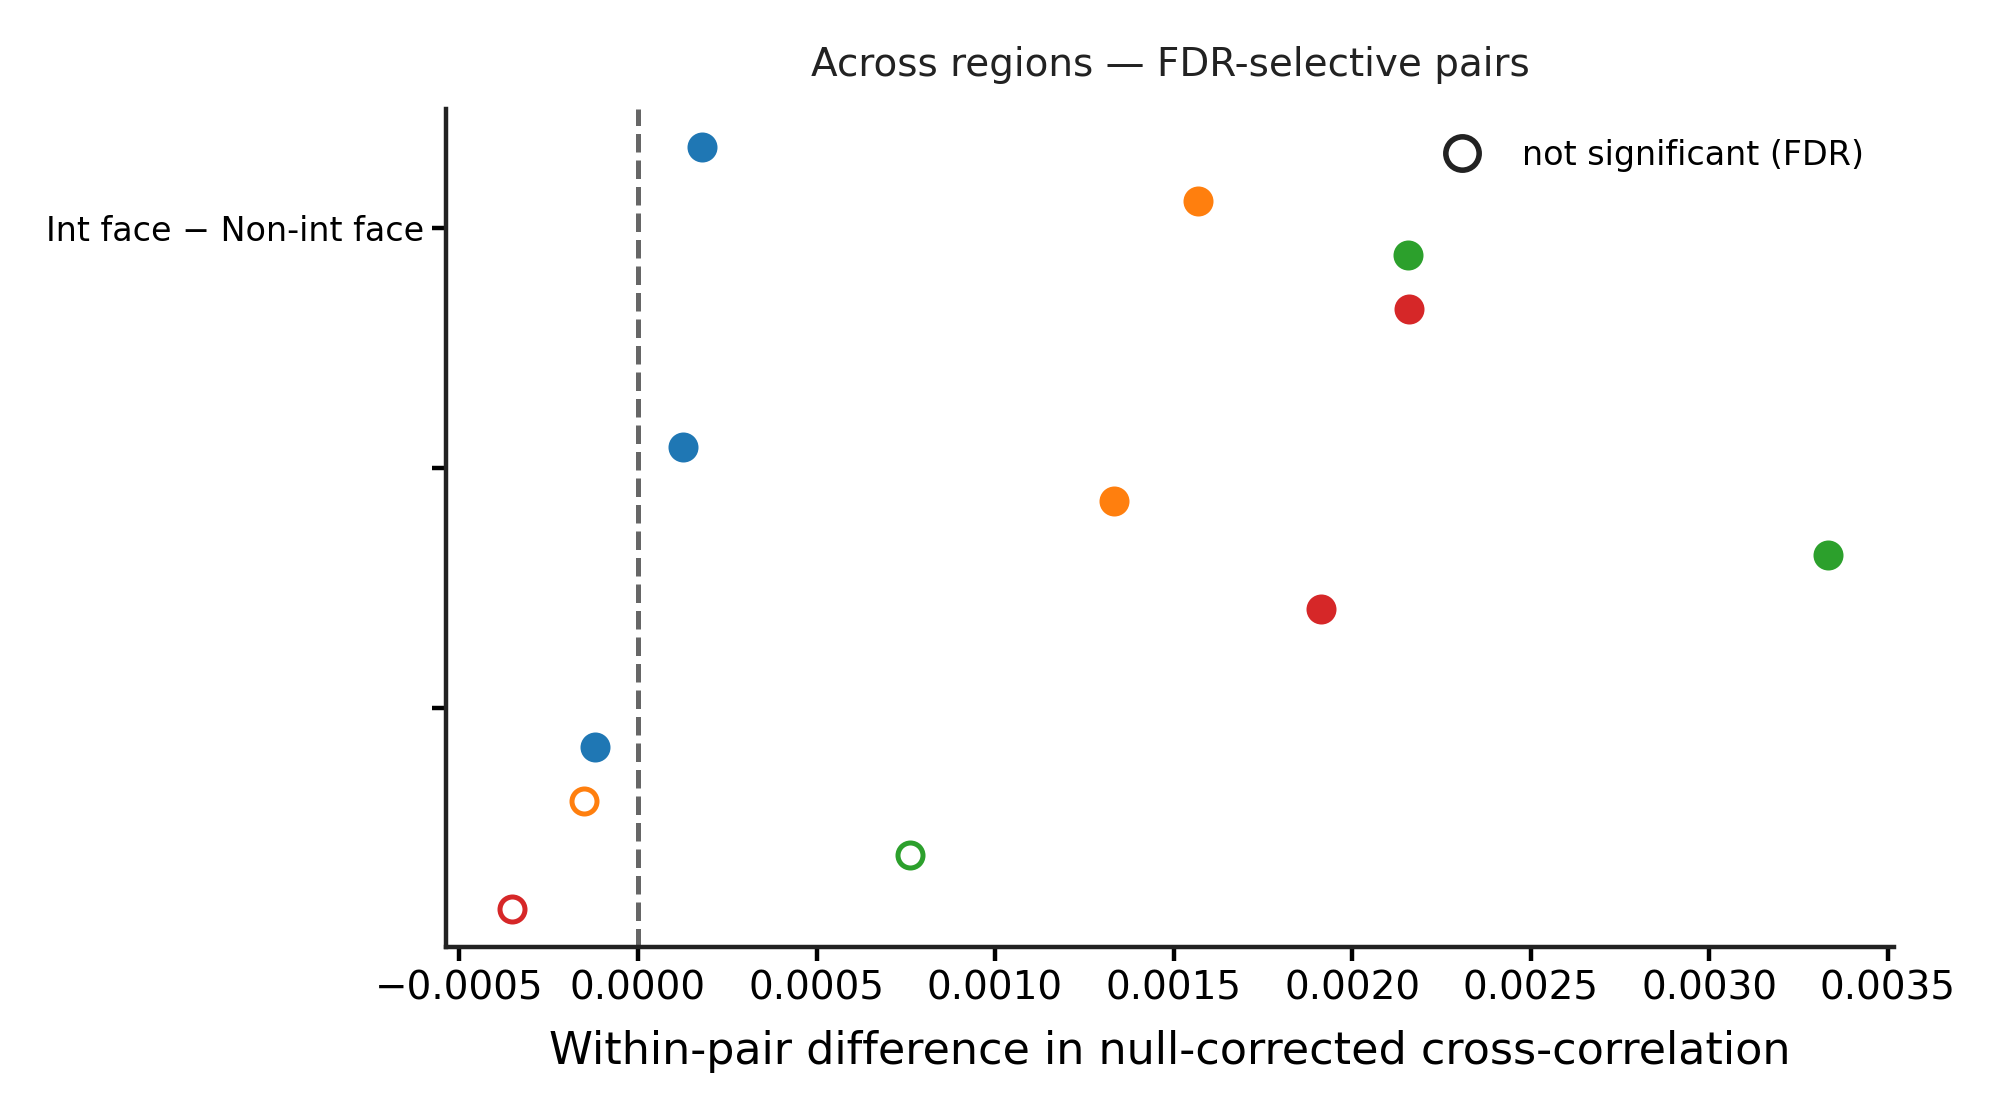

In [11]:
fig, paths = viz.plot_null_corrected_grid(
    traces_sig, figs, scope="cross_region", min_pairs=MIN_PAIRS, label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

subset = contrasts_sig.loc[contrasts_sig["scope"] == "cross_region"]
display(subset.round(4))

fig, paths = viz.plot_condition_contrasts(
    contrasts_sig, figs, scope="cross_region", label="FDR-selective pairs"
)
display(Image(filename=str(paths["png"])))

# Supporting

## Is there coordination above null at all?

Secondary to the condition comparison, but worth confirming there is something
to compare. One-sample Wilcoxon of the per-pair excess against zero, per region
and condition, using `z` — the right quantity for this question and the wrong
one for comparing conditions, since it scales with the square root of the
fixation count.

In [12]:
display(pd.read_csv(SUMMARY_DIR / "vs_null_by_region.csv").round(4))

,scope,region_pair,condition,n_pairs,mean_excess,median_excess,statistic,p_value
0,cross_region,accg-bla,face_interactive,21552,0.0714,0.0187,131210009.0,0.0000
1,cross_region,accg-bla,face_non_interactive,14475,0.0481,-0.0240,54914301.0,0.0000
2,cross_region,accg-bla,object,17194,0.0614,-0.0025,82259548.0,0.0000
3,cross_region,accg-dmpfc,face_interactive,4825,0.0825,0.0302,6853503.0,0.0000
4,cross_region,accg-dmpfc,face_non_interactive,3250,0.0453,-0.0259,2799993.0,0.0012
5,cross_region,accg-dmpfc,object,3696,0.0375,-0.0203,3612876.0,0.0009
6,cross_region,bla-dmpfc,face_interactive,31510,0.1290,0.0540,304236627.0,0.0000
7,cross_region,bla-dmpfc,face_non_interactive,23288,0.0630,-0.0094,148420834.0,0.0000
8,cross_region,bla-dmpfc,object,23913,0.0574,-0.0060,156805637.0,0.0000
9,cross_region,bla-ofc,face_interactive,20231,0.0849,0.0251,117189286.0,0.0000


## The zero-lag artifact

Two randomly sampled neurons are essentially never monosynaptically connected,
so a sharp zero-lag peak shared by most pairs on a day is common input —
movement, arousal, or a shared reference/ground artifact. It is a property of
the **day and array**, not of the pair, so flagged days are removed from every
result above rather than noted here.

**2 date(s) removed from every result above:** ['1302018', '9292018']

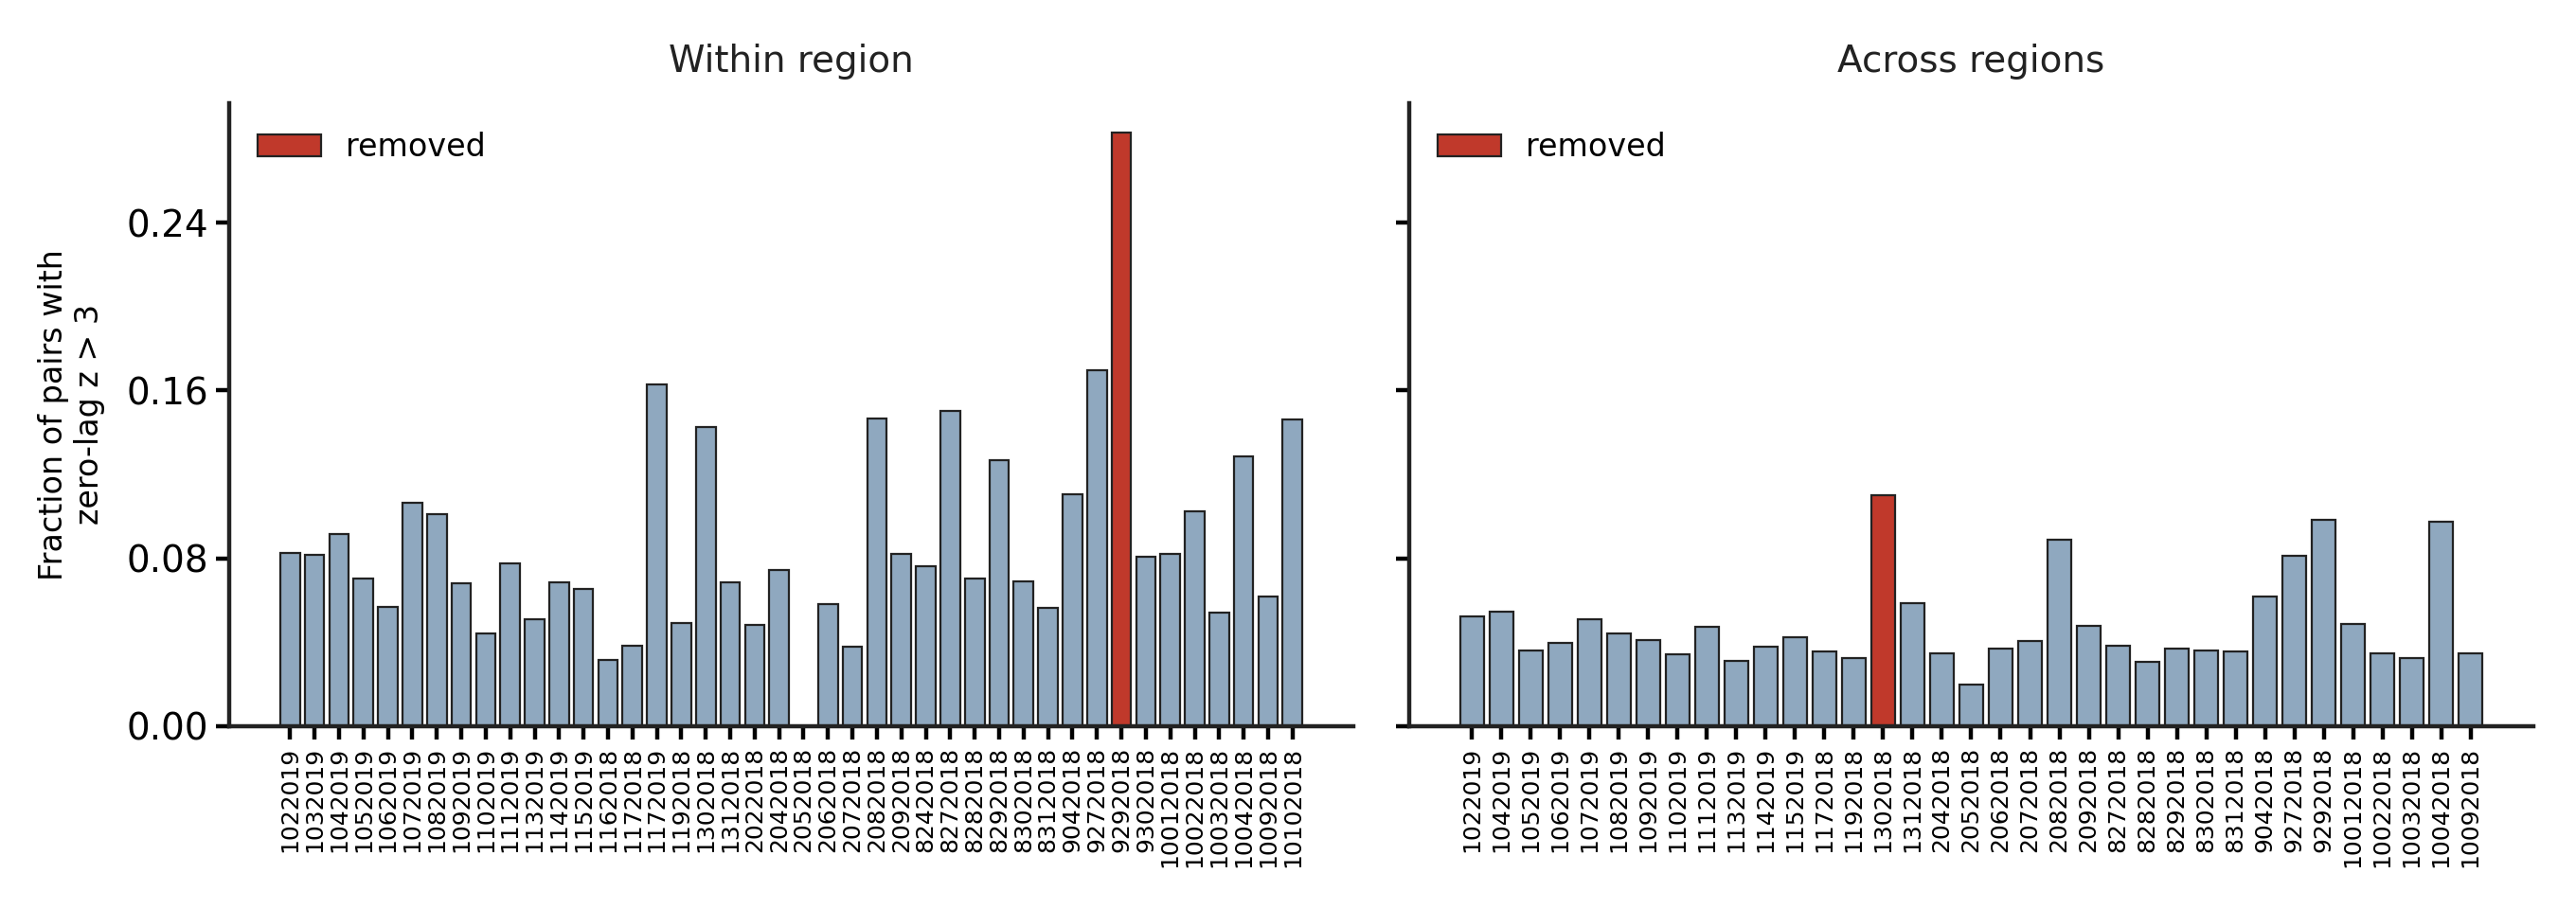

In [13]:
dropped = pd.read_csv(SUMMARY_DIR / "dropped_artifact_dates.csv")
if len(dropped):
    display(Markdown(
        f"**{len(dropped)} date(s) removed from every result above:** "
        f"{sorted(dropped['date'].astype(str))}"
    ))
else:
    display(Markdown("_No date was flagged._"))

diagnostics = pd.read_csv(SUMMARY_DIR / "zero_lag_diagnostics.csv")
fig, paths = viz.plot_zero_lag_diagnostics(diagnostics, figs)
display(Image(filename=str(paths["png"])))